# DDoS Attacks Detection and Characterization


In [247]:
import pandas as pd
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import datetime 
import ipaddress

from sklearn.utils import resample
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, rand_score 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance


In [248]:
df = pd.read_csv('ddos_dataset.csv',low_memory=False)

# we create a copy of the original dataset
df_copy = df.copy()
df

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
0,0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
1,1,172.16.0.5-192.168.50.1-60495-634-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,ddos_dns
2,2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
3,3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
4,4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,65995,172.16.0.5-192.168.50.1-38625-63051-17,172.16.0.5,38625,192.168.50.1,63051,17,2018-12-01 13:04:46.628249,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag
64235,65996,172.16.0.5-192.168.50.1-58632-18963-17,172.16.0.5,58632,192.168.50.1,18963,17,2018-12-01 13:04:46.628963,212238,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag
64236,65997,172.16.0.5-192.168.50.1-46104-64704-17,172.16.0.5,46104,192.168.50.1,64704,17,2018-12-01 13:04:46.629014,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag
64237,65998,172.16.0.5-192.168.50.1-60686-10440-17,172.16.0.5,60686,192.168.50.1,10440,17,2018-12-01 13:04:46.629016,108952,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag


# Section 1 – Data exploration and pre-processing

## 1. Investigate the provided DDoS attack dataset

I dati sono stati raccolti il giorno 1 dicembre 2018 dalle 09:17:11 alle 13:34:27. TODO: Da tradurre

In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64239 entries, 0 to 64238
Data columns (total 88 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    64239 non-null  int64  
 1   Flow ID                       64239 non-null  object 
 2    Source IP                    64239 non-null  object 
 3    Source Port                  64239 non-null  int64  
 4    Destination IP               64239 non-null  object 
 5    Destination Port             64239 non-null  int64  
 6    Protocol                     64239 non-null  int64  
 7    Timestamp                    64239 non-null  object 
 8    Flow Duration                64239 non-null  int64  
 9    Total Fwd Packets            64239 non-null  int64  
 10   Total Backward Packets       64239 non-null  int64  
 11  Total Length of Fwd Packets   64239 non-null  float64
 12   Total Length of Bwd Packets  64239 non-null  float64
 13   

In [250]:
# we fix column names
df.columns = [col.strip().replace(" ", "") for col in df.columns] 

# we drop the first column which is unnecessary
df.drop(columns=['Unnamed:0'],inplace=True)

# we put 1 when the value of SimilarHTTP is different from zero
df['SimillarHTTP'] = df['SimillarHTTP'].apply(lambda x : 1 if x != 0 else 0)
print(df['SimillarHTTP'].value_counts())
df.head()

SimillarHTTP
1    64239
Name: count, dtype: int64


,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,SimillarHTTP,Inbound,label
0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns
1,172.16.0.5-192.168.50.1-60495-634-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,ddos_dns
2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns
3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns
4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns


We now remove columns that have the same value in every row.

In [251]:
unique_val = df.apply(lambda col: col.unique())

col_unique_val = unique_val[unique_val.apply(len) == 1].index

print("Columns meaningless beacuse they have the same value on all rows:")
print(col_unique_val)

df.drop(columns=col_unique_val,inplace=True)

print(f"The dataset has now {df.shape[0]} rows and {df.shape[1]}")

Columns meaningless beacuse they have the same value on all rows:
Index(['BwdPSHFlags', 'FwdURGFlags', 'BwdURGFlags', 'FINFlagCount',
       'PSHFlagCount', 'ECEFlagCount', 'FwdAvgBytes/Bulk',
       'FwdAvgPackets/Bulk', 'FwdAvgBulkRate', 'BwdAvgBytes/Bulk',
       'BwdAvgPackets/Bulk', 'BwdAvgBulkRate', 'SimillarHTTP'],
      dtype='object')
The dataset has now 64239 rows and 74


In [252]:
df.describe()

,SourcePort,DestinationPort,Protocol,FlowDuration,TotalFwdPackets,TotalBackwardPackets,TotalLengthofFwdPackets,TotalLengthofBwdPackets,FwdPacketLengthMax,FwdPacketLengthMin,...,min_seg_size_forward,ActiveMean,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,Inbound
count,64239.000000,64239.000000,64239.000000,6.423900e+04,64239.000000,64239.000000,64239.000000,6.423900e+04,64239.000000,64239.000000,...,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,64239.000000
mean,25267.368608,30715.252884,14.362864,5.150614e+06,18.814848,1.304036,6699.521630,2.153348e+03,613.992948,588.863043,...,-4.167229e+07,9.026629e+03,4.878774e+03,1.687791e+04,6.204895e+03,1.155553e+06,2.613584e+05,1.555321e+06,8.908522e+05,0.919566
std,24710.413442,20347.990914,4.706001,2.249713e+07,462.305336,25.199720,20510.320389,9.087201e+04,585.691655,584.276284,...,2.062767e+08,2.045563e+05,1.424082e+05,3.828583e+05,1.667756e+05,5.341380e+06,1.574889e+06,6.993415e+06,4.571276e+06,0.271966
min,0.000000,0.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,-1.062719e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,779.000000,12435.500000,17.000000,1.000000e+00,2.000000,0.000000,123.000000,0.000000e+00,53.000000,36.000000,...,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
50%,29661.000000,30797.000000,17.000000,2.000000e+00,2.000000,0.000000,1050.000000,0.000000e+00,393.000000,375.000000,...,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,48510.500000,49041.500000,17.000000,2.087700e+04,2.000000,0.000000,2944.000000,0.000000e+00,1464.000000,1464.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,65518.000000,65535.000000,17.000000,1.200000e+08,85894.000000,1862.000000,176000.000000,8.829488e+06,3564.000000,2020.000000,...,1.480000e+03,1.678654e+07,2.853681e+07,6.783473e+07,8.349846e+06,1.147455e+08,5.275036e+07,1.147455e+08,1.147455e+08,1.000000


In [253]:
df['FlowID']=df["SourceIP"] + "-" + df["DestinationIP"] + "-" + \
               df["SourcePort"].astype(str) + "-" + \
               df["DestinationPort"].astype(str) + "-" + \
               df["Protocol"].astype(str)
df

,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,ActiveMean,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,Inbound,label
0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
1,192.168.50.1-172.16.0.5-634-60495-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos_dns
2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,172.16.0.5-192.168.50.1-38625-63051-17,172.16.0.5,38625,192.168.50.1,63051,17,2018-12-01 13:04:46.628249,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag
64235,172.16.0.5-192.168.50.1-58632-18963-17,172.16.0.5,58632,192.168.50.1,18963,17,2018-12-01 13:04:46.628963,212238,6,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag
64236,172.16.0.5-192.168.50.1-46104-64704-17,172.16.0.5,46104,192.168.50.1,64704,17,2018-12-01 13:04:46.629014,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag
64237,172.16.0.5-192.168.50.1-60686-10440-17,172.16.0.5,60686,192.168.50.1,10440,17,2018-12-01 13:04:46.629016,108952,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag


### BASIC TRAFFIC STATISTICS

In [254]:
n_flow=df['FlowID'].nunique() # 64239
n_src_ip = df["SourceIP"].nunique()
n_dst_ip = df["DestinationIP"].nunique()

print(f"Number of unique source IPs: {n_src_ip}")
print(f"Number of unique destination IPs: {n_dst_ip}")
n_flow

Number of unique source IPs: 216
Number of unique destination IPs: 245


62154

### LABEL DISTRIBUTION

In [255]:
df_masked=df[df['label']=='benign']
num_benign=df_masked['label'].count() # 5658

num_attack=len(df)-num_benign # 58581
num_attackpertype=df[df['label']!='benign'].groupby(["label"]).size()   # int(num_attacktype[i])
num_attackpertype

label
ddos_dns        5369
ddos_ldap       5928
ddos_mssql      5911
ddos_netbios    5830
ddos_ntp         986
ddos_snmp       5984
ddos_ssdp       5970
ddos_syn        5480
ddos_tftp       5261
ddos_udp        5876
ddos_udp_lag    5986
dtype: int64

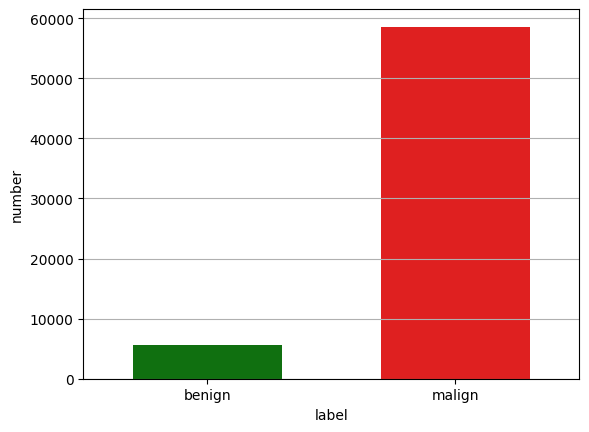

In [256]:
df_benign= pd.DataFrame({
    'label' : ['benign','malign'], 
    'number' : [num_benign, num_attack]
})

sns.barplot(
    data = df_benign, # which dataframe you want to use as the source data
    x = 'label', # which column to use for x-axis
    y = 'number', # which column to use for y-axis
    width=0.6,
    palette = ['green', 'red'],
    hue = 'label',
    legend = False
)
plt.grid(True)             
plt.grid(axis='x')
plt.show()

### TRAFIC LEVEL DISTRIBUITION

#### PROTOCOL

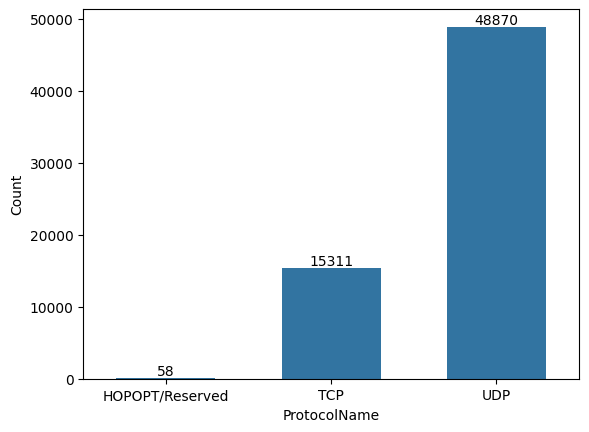

In [257]:
prt_map = {
    6: 'TCP',
    17: 'UDP',
    0: 'HOPOPT/Reserved'
}


df['ProtocolName'] = df['Protocol'].replace(prt_map)

df_prot=df.groupby('ProtocolName')['ProtocolName'].count()
df_prot=pd.DataFrame(df_prot)
df_prot.columns=['Count']

ax = sns.barplot(data = df_prot, x = df_prot.index, y = 'Count', width=0.6)

# Aggiungere i valori sopra le barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')
plt.show()

### IP SOURCE/DESTINATION 

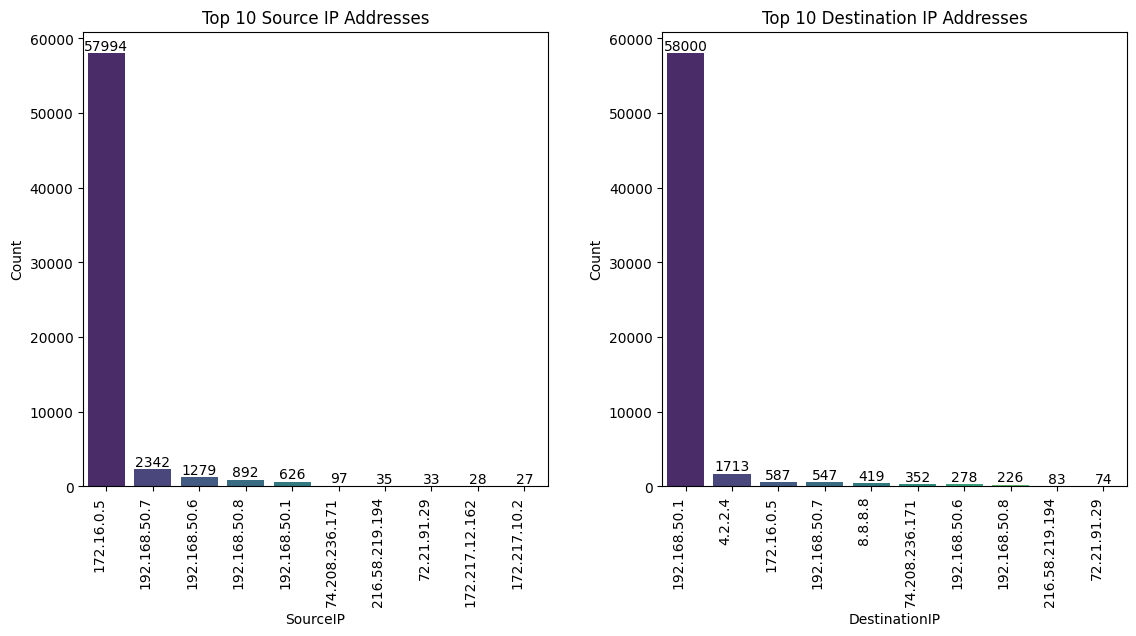

In [258]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
IP_Source_dist = df['SourceIP'].value_counts().head(10)
IP_Source_dist = pd.DataFrame(IP_Source_dist)
IP_Source_dist.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist,
    x = 'SourceIP',
    y = 'Count',
    palette='viridis',
    hue = 'SourceIP',
    legend = False
    
)
plt.title('Top 10 Source IP Addresses')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.subplot(1,2,2)
IP_Destination_dist = df['DestinationIP'].value_counts().head(10)
IP_Destination_dist = pd.DataFrame(IP_Destination_dist)
IP_Destination_dist.columns = ['Count']
ax = sns.barplot(
    data = IP_Destination_dist,
    x = 'DestinationIP',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationIP',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Destination IP Addresses')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

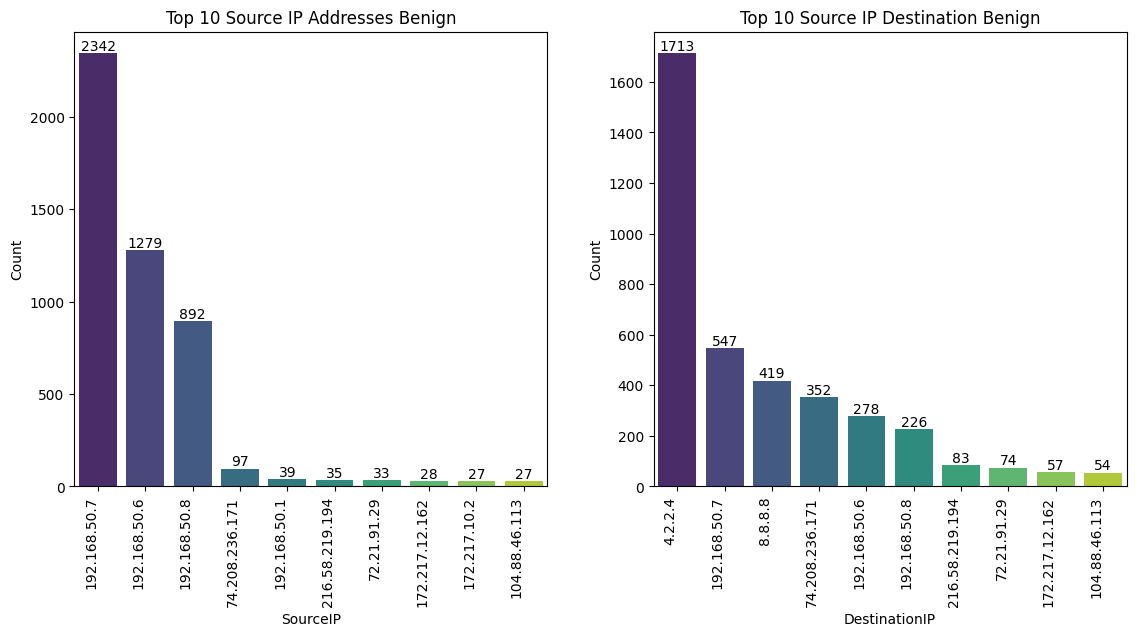

In [259]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
IP_Source_dist_Benign = df['SourceIP'][df['label'] == 'benign'].value_counts().head(10)
IP_Source_dist_Benign = pd.DataFrame(IP_Source_dist_Benign)
IP_Source_dist_Benign.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist_Benign,
    x = 'SourceIP',
    y = 'Count',
    palette='viridis',
    hue = 'SourceIP',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source IP Addresses Benign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.subplot(1,2,2)
IP_Source_dist_Benign = df['DestinationIP'][df['label'] == 'benign'].value_counts().head(10)
IP_Source_dist_Benign = pd.DataFrame(IP_Source_dist_Benign)
IP_Source_dist_Benign.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist_Benign,
    x = 'DestinationIP',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationIP',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source IP Destination Benign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

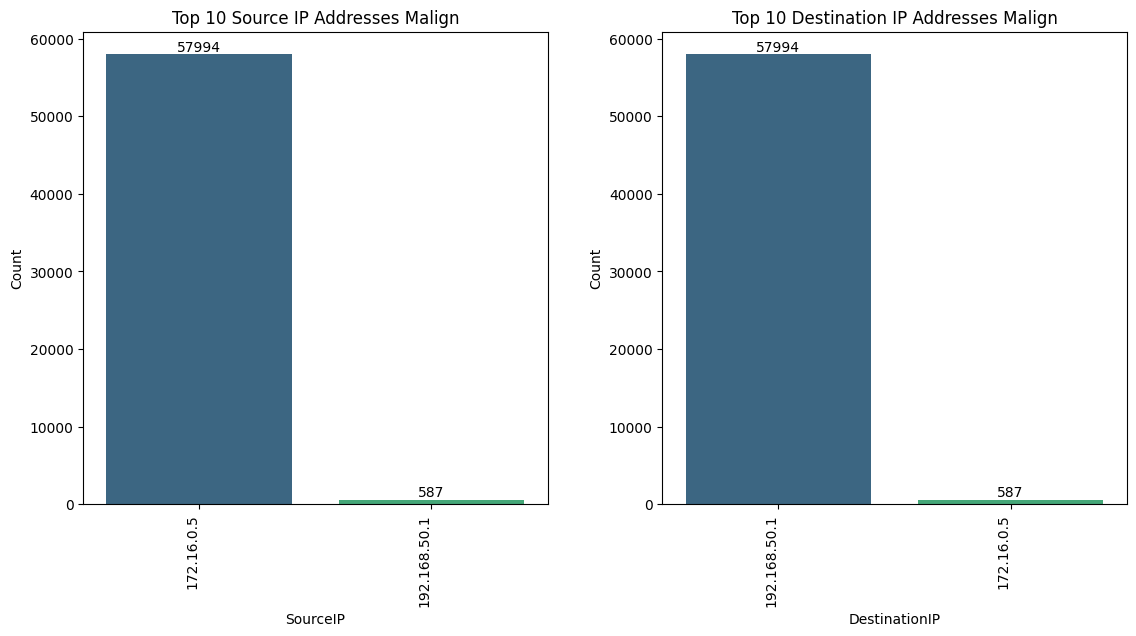

In [260]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
IP_Source_dist_Malign = df['SourceIP'][df['label'] != 'benign'].value_counts().head(10)
IP_Source_dist_Malign = pd.DataFrame(IP_Source_dist_Malign)
IP_Source_dist_Malign.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist_Malign,
    x = 'SourceIP',
    y = 'Count',
    palette='viridis',
    hue = 'SourceIP',
    legend = False
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source IP Addresses Malign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.subplot(1,2,2)
IP_Destination_dist_Malign = df['DestinationIP'][df['label'] != 'benign'].value_counts().head(10)
IP_Destination_dist_Malign = pd.DataFrame(IP_Destination_dist_Malign)
IP_Destination_dist_Malign.columns = ['Count']
ax = sns.barplot(
    data = IP_Destination_dist_Malign,
    x = 'DestinationIP',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationIP',
    legend = False
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Destination IP Addresses Malign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')




plt.tight_layout(pad=3)

### TOP 10 DESTINATION/SOURCE PORTS 

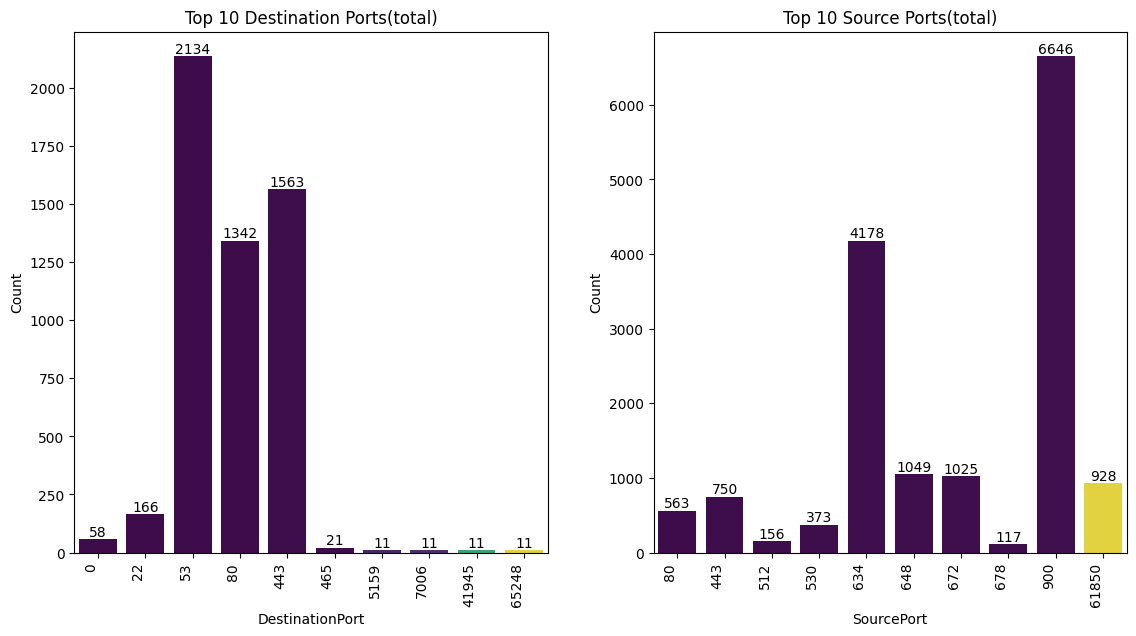

In [261]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
Destination_Port_dist = df['DestinationPort'].value_counts().head(10)
Destination_Port_dist = pd.DataFrame(Destination_Port_dist)
Destination_Port_dist.columns = ['Count']
ax = sns.barplot(
    data = Destination_Port_dist,
    x = 'DestinationPort',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationPort',
    legend = False
    
)
plt.title('Top 10 Destination Ports(total)')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')


# secondo subplot, quello a destra
plt.subplot(1,2,2)
Source_Port_dist= df['SourcePort'].value_counts().head(10)
Source_Port_dist = pd.DataFrame(Source_Port_dist)
Source_Port_dist.columns = ['Count']
ax = sns.barplot(
    data = Source_Port_dist,
    x = 'SourcePort',
    y = 'Count',
    palette='viridis',
    hue = 'SourcePort',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source Ports(total)')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

### TOP 10 DESTINATION / SOURCE PORTS (BENIGN)

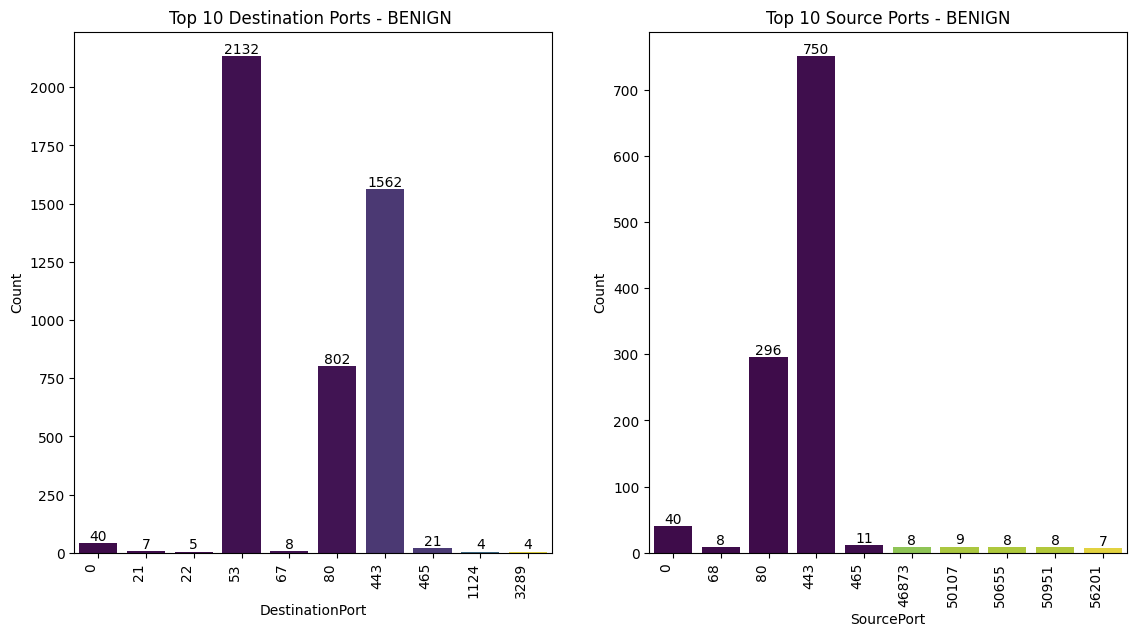

In [262]:
plt.figure(figsize=(12, 7))
plt.subplot(1,2,1)
Destination_Port_dist_Benign = df['DestinationPort'][df['label'] == 'benign'].value_counts().head(10)
Destination_Port_dist_Benign = pd.DataFrame(Destination_Port_dist_Benign)
Destination_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Destination_Port_dist_Benign,
x = 'DestinationPort',
y = 'Count',
palette='viridis',
hue = 'DestinationPort',
legend = False

)
plt.title('Top 10 Destination Ports - BENIGN ')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# secondo subplot, quello a destra

plt.subplot(1,2,2)
Source_Port_dist_Benign= df['SourcePort'][df['label'] == 'benign'].value_counts().head(10)
Source_Port_dist_Benign = pd.DataFrame(Source_Port_dist_Benign)
Source_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Source_Port_dist_Benign,
x = 'SourcePort',
y = 'Count',
palette='viridis',
hue = 'SourcePort',
legend = False

)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source Ports - BENIGN')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

### TOP 10 DESTINATION / SOURCE PORTS (MALIGN)

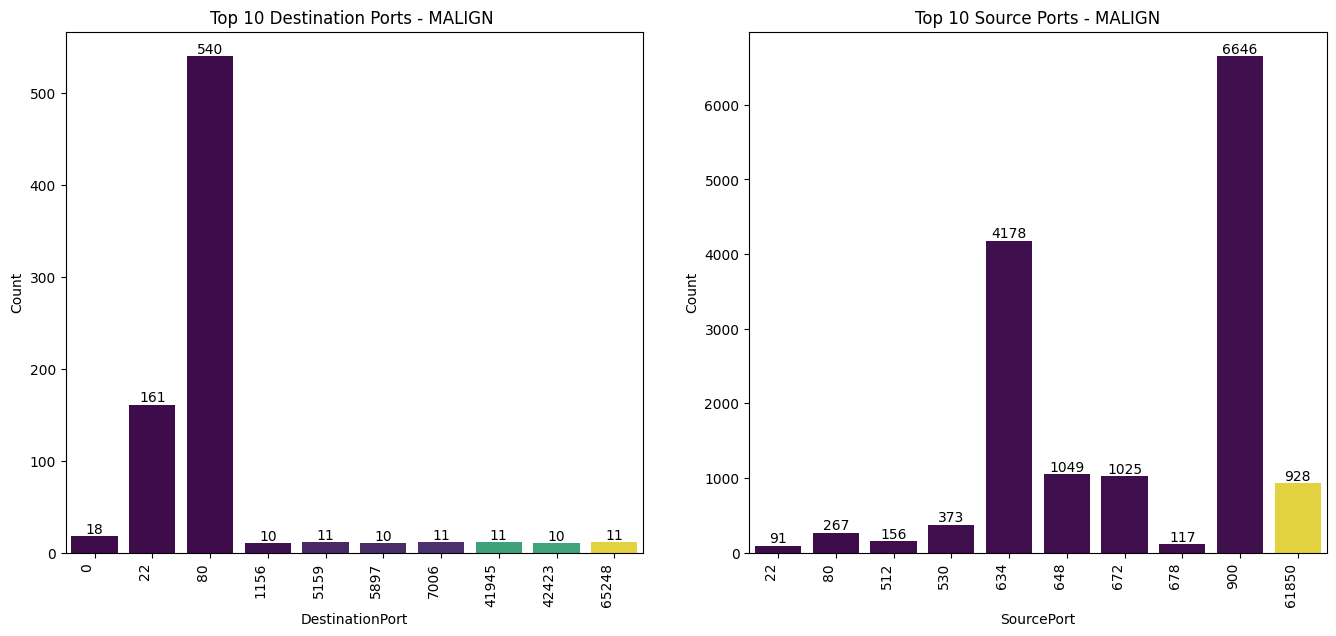

In [263]:
plt.figure(figsize=(14, 7))
plt.subplot(1,2,1)
Destination_Port_dist_Benign = df['DestinationPort'][df['label'] != 'benign'].value_counts().head(10)
Destination_Port_dist_Benign = pd.DataFrame(Destination_Port_dist_Benign)
Destination_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Destination_Port_dist_Benign,
x = 'DestinationPort',
y = 'Count',
palette='viridis',
hue = 'DestinationPort',
legend = False

)
plt.title('Top 10 Destination Ports - MALIGN ')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# secondo subplot, quello a destra

plt.subplot(1,2,2)
Source_Port_dist_Benign= df['SourcePort'][df['label'] != 'benign'].value_counts().head(10)
Source_Port_dist_Benign = pd.DataFrame(Source_Port_dist_Benign)
Source_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Source_Port_dist_Benign,
x = 'SourcePort',
y = 'Count',
palette='viridis',
hue = 'SourcePort',
legend = False

)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source Ports - MALIGN')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

In [264]:
df['label_simplified']= df['label'].apply(lambda x: "benign" if x=='benign' else "attack")

<Axes: xlabel='DestinationPort', ylabel='Proportion'>

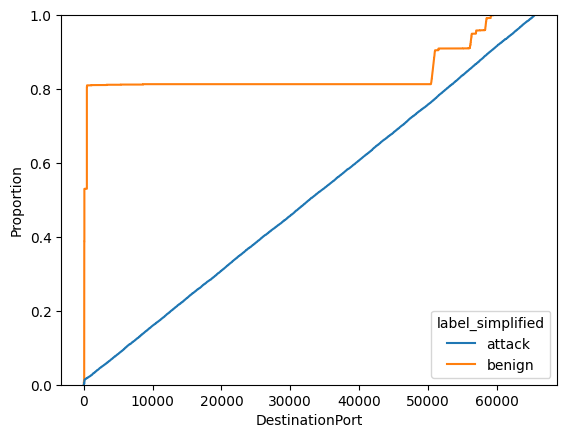

In [265]:
sns.ecdfplot(
    data = df,
    x = 'DestinationPort', # the column that you want to compute ecdf, they will be in the order from short to long length (numerical order)
    hue = 'label_simplified')

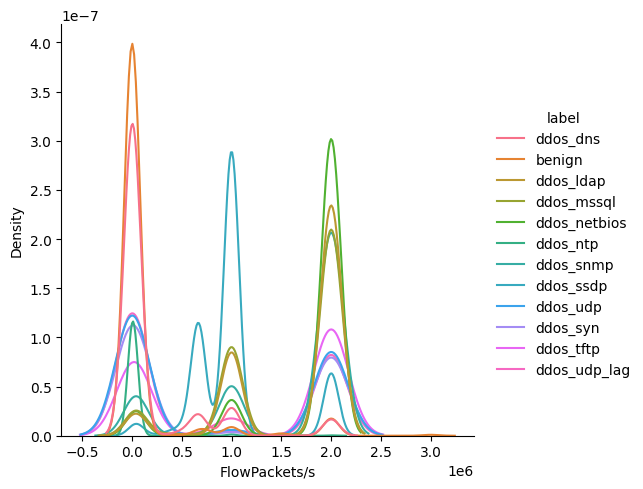

In [266]:
sns.displot(
    data = df, 
    x = "FlowPackets/s", # the column you want to check
    hue = "label", # check the distribution of different flower types
    kind = "kde" # a kernel density estimate (KDE) of the distribution, you can remove this to see the change
)

/tmp/ipykernel_5757/1905931592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_masked['Timestamp'] = pd.to_datetime(df_masked['Timestamp'])


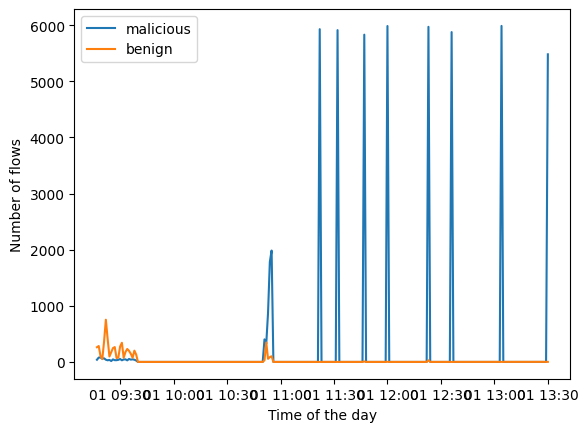

In [267]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_masked['Timestamp'] = pd.to_datetime(df_masked['Timestamp'])

df_time_b=df_masked.set_index('Timestamp')
df_time_b=df_time_b.resample('1min').size()

df_time=df.set_index('Timestamp')
df_time=df_time.resample('1min').size()
df_time_m=df_time-df_time_b

plt.figure()
sns.lineplot(data = df_time_m, label='malicious')
sns.lineplot(data = df_time_b,label='benign')
plt.xlabel("Time of the day")
plt.ylabel("Number of flows")
plt.show()

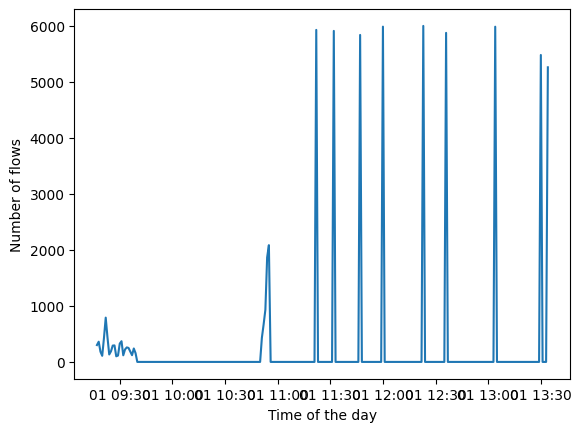

In [268]:
plt.figure()
sns.lineplot(data = df_time)
plt.xlabel("Time of the day")
plt.ylabel("Number of flows")
plt.show()

## 2. Generate additional features

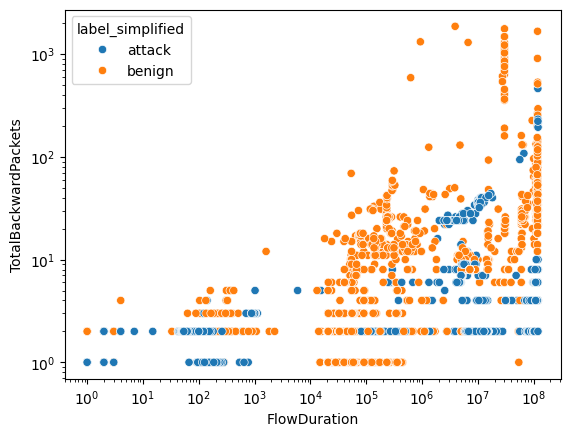

In [269]:
df['TotalBytes'] = df['TotalLengthofFwdPackets'] + df['TotalLengthofBwdPackets']
df['TotalPackets'] = df['TotalFwdPackets'] + df['TotalBackwardPackets']
df['AveragePacketLength'] = df['TotalBytes'] / df['TotalPackets']

df['Fwd/BwdPacketRatio'] = df['TotalFwdPackets'] / (df['TotalBackwardPackets'] + 1)

df['TrafficScore'] = df['TotalBytes'] * df['FlowPackets/s']

sns.scatterplot(
    data=df,
    x='FlowDuration',
    y='TotalBackwardPackets', # ????????
    hue='label_simplified') 
plt.xscale('log')
plt.yscale('log')
plt.show()

## 3. Data Pre-processing
### Categorial features encoding
#### Time

In [270]:
reference_date = min(df['Timestamp'])
df['Timestamp'] = (df['Timestamp'] - reference_date).dt.total_seconds()

In [271]:
df

,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,IdleMin,Inbound,label,ProtocolName,label_simplified,TotalBytes,TotalPackets,AveragePacketLength,Fwd/BwdPacketRatio,TrafficScore
0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,5668.629638,28415,97,0,...,0.0,1,ddos_dns,UDP,attack,42680.0,97,440.0,97.0,1.456963e+08
1,192.168.50.1-172.16.0.5-634-60495-17,192.168.50.1,634,172.16.0.5,60495,17,5668.637032,2,2,0,...,0.0,0,ddos_dns,UDP,attack,880.0,2,440.0,2.0,8.800000e+08
2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,5668.668689,48549,200,0,...,0.0,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.625203e+08
3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,5668.706403,48337,200,0,...,0.0,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.641103e+08
4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,5668.757341,32026,200,0,...,0.0,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,5.495535e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,172.16.0.5-192.168.50.1-38625-63051-17,172.16.0.5,38625,192.168.50.1,63051,17,13655.444439,1,2,0,...,0.0,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09
64235,172.16.0.5-192.168.50.1-58632-18963-17,172.16.0.5,58632,192.168.50.1,18963,17,13655.445153,212238,6,0,...,0.0,1,ddos_udp_lag,UDP,attack,2088.0,6,348.0,6.0,5.902807e+04
64236,172.16.0.5-192.168.50.1-46104-64704-17,172.16.0.5,46104,192.168.50.1,64704,17,13655.445204,1,2,0,...,0.0,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09
64237,172.16.0.5-192.168.50.1-60686-10440-17,172.16.0.5,60686,192.168.50.1,10440,17,13655.445206,108952,4,0,...,0.0,1,ddos_udp_lag,UDP,attack,1438.0,4,359.5,4.0,5.279389e+04


#### Source IP, Destination IP and label

In [272]:
categorical_features=['label','SourceIP','DestinationIP']

label_encoder = LabelEncoder()
for feature in categorical_features:
    if feature == 'label':
        df['IntLabel'] = label_encoder.fit_transform(df[feature])
    else:  
        df[feature] = label_encoder.fit_transform(df[feature])

df

,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,Inbound,label,ProtocolName,label_simplified,TotalBytes,TotalPackets,AveragePacketLength,Fwd/BwdPacketRatio,TrafficScore,IntLabel
0,172.16.0.5-192.168.50.1-634-60495-17,16,634,90,60495,17,5668.629638,28415,97,0,...,1,ddos_dns,UDP,attack,42680.0,97,440.0,97.0,1.456963e+08,1
1,192.168.50.1-172.16.0.5-634-60495-17,75,634,23,60495,17,5668.637032,2,2,0,...,0,ddos_dns,UDP,attack,880.0,2,440.0,2.0,8.800000e+08,1
2,172.16.0.5-192.168.50.1-634-46391-17,16,634,90,46391,17,5668.668689,48549,200,0,...,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.625203e+08,1
3,172.16.0.5-192.168.50.1-634-11894-17,16,634,90,11894,17,5668.706403,48337,200,0,...,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.641103e+08,1
4,172.16.0.5-192.168.50.1-634-27878-17,16,634,90,27878,17,5668.757341,32026,200,0,...,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,5.495535e+08,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,172.16.0.5-192.168.50.1-38625-63051-17,16,38625,90,63051,17,13655.444439,1,2,0,...,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09,11
64235,172.16.0.5-192.168.50.1-58632-18963-17,16,58632,90,18963,17,13655.445153,212238,6,0,...,1,ddos_udp_lag,UDP,attack,2088.0,6,348.0,6.0,5.902807e+04,11
64236,172.16.0.5-192.168.50.1-46104-64704-17,16,46104,90,64704,17,13655.445204,1,2,0,...,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09,11
64237,172.16.0.5-192.168.50.1-60686-10440-17,16,60686,90,10440,17,13655.445206,108952,4,0,...,1,ddos_udp_lag,UDP,attack,1438.0,4,359.5,4.0,5.279389e+04,11


#### StandardScaler

In [273]:
labels=df[['IntLabel']].copy()
label_df=df[['label']].copy()
time=df[['Timestamp']].copy()
time.rename(columns={'Timestamp': 'Time'}, inplace=True)
tmp=df.drop(columns=['label','IntLabel','label_simplified','FlowID','ProtocolName'])

scaler=StandardScaler()
df_scale=scaler.fit_transform(tmp)
df_scale=pd.DataFrame(df_scale, columns=tmp.columns)

### Correlation matrix

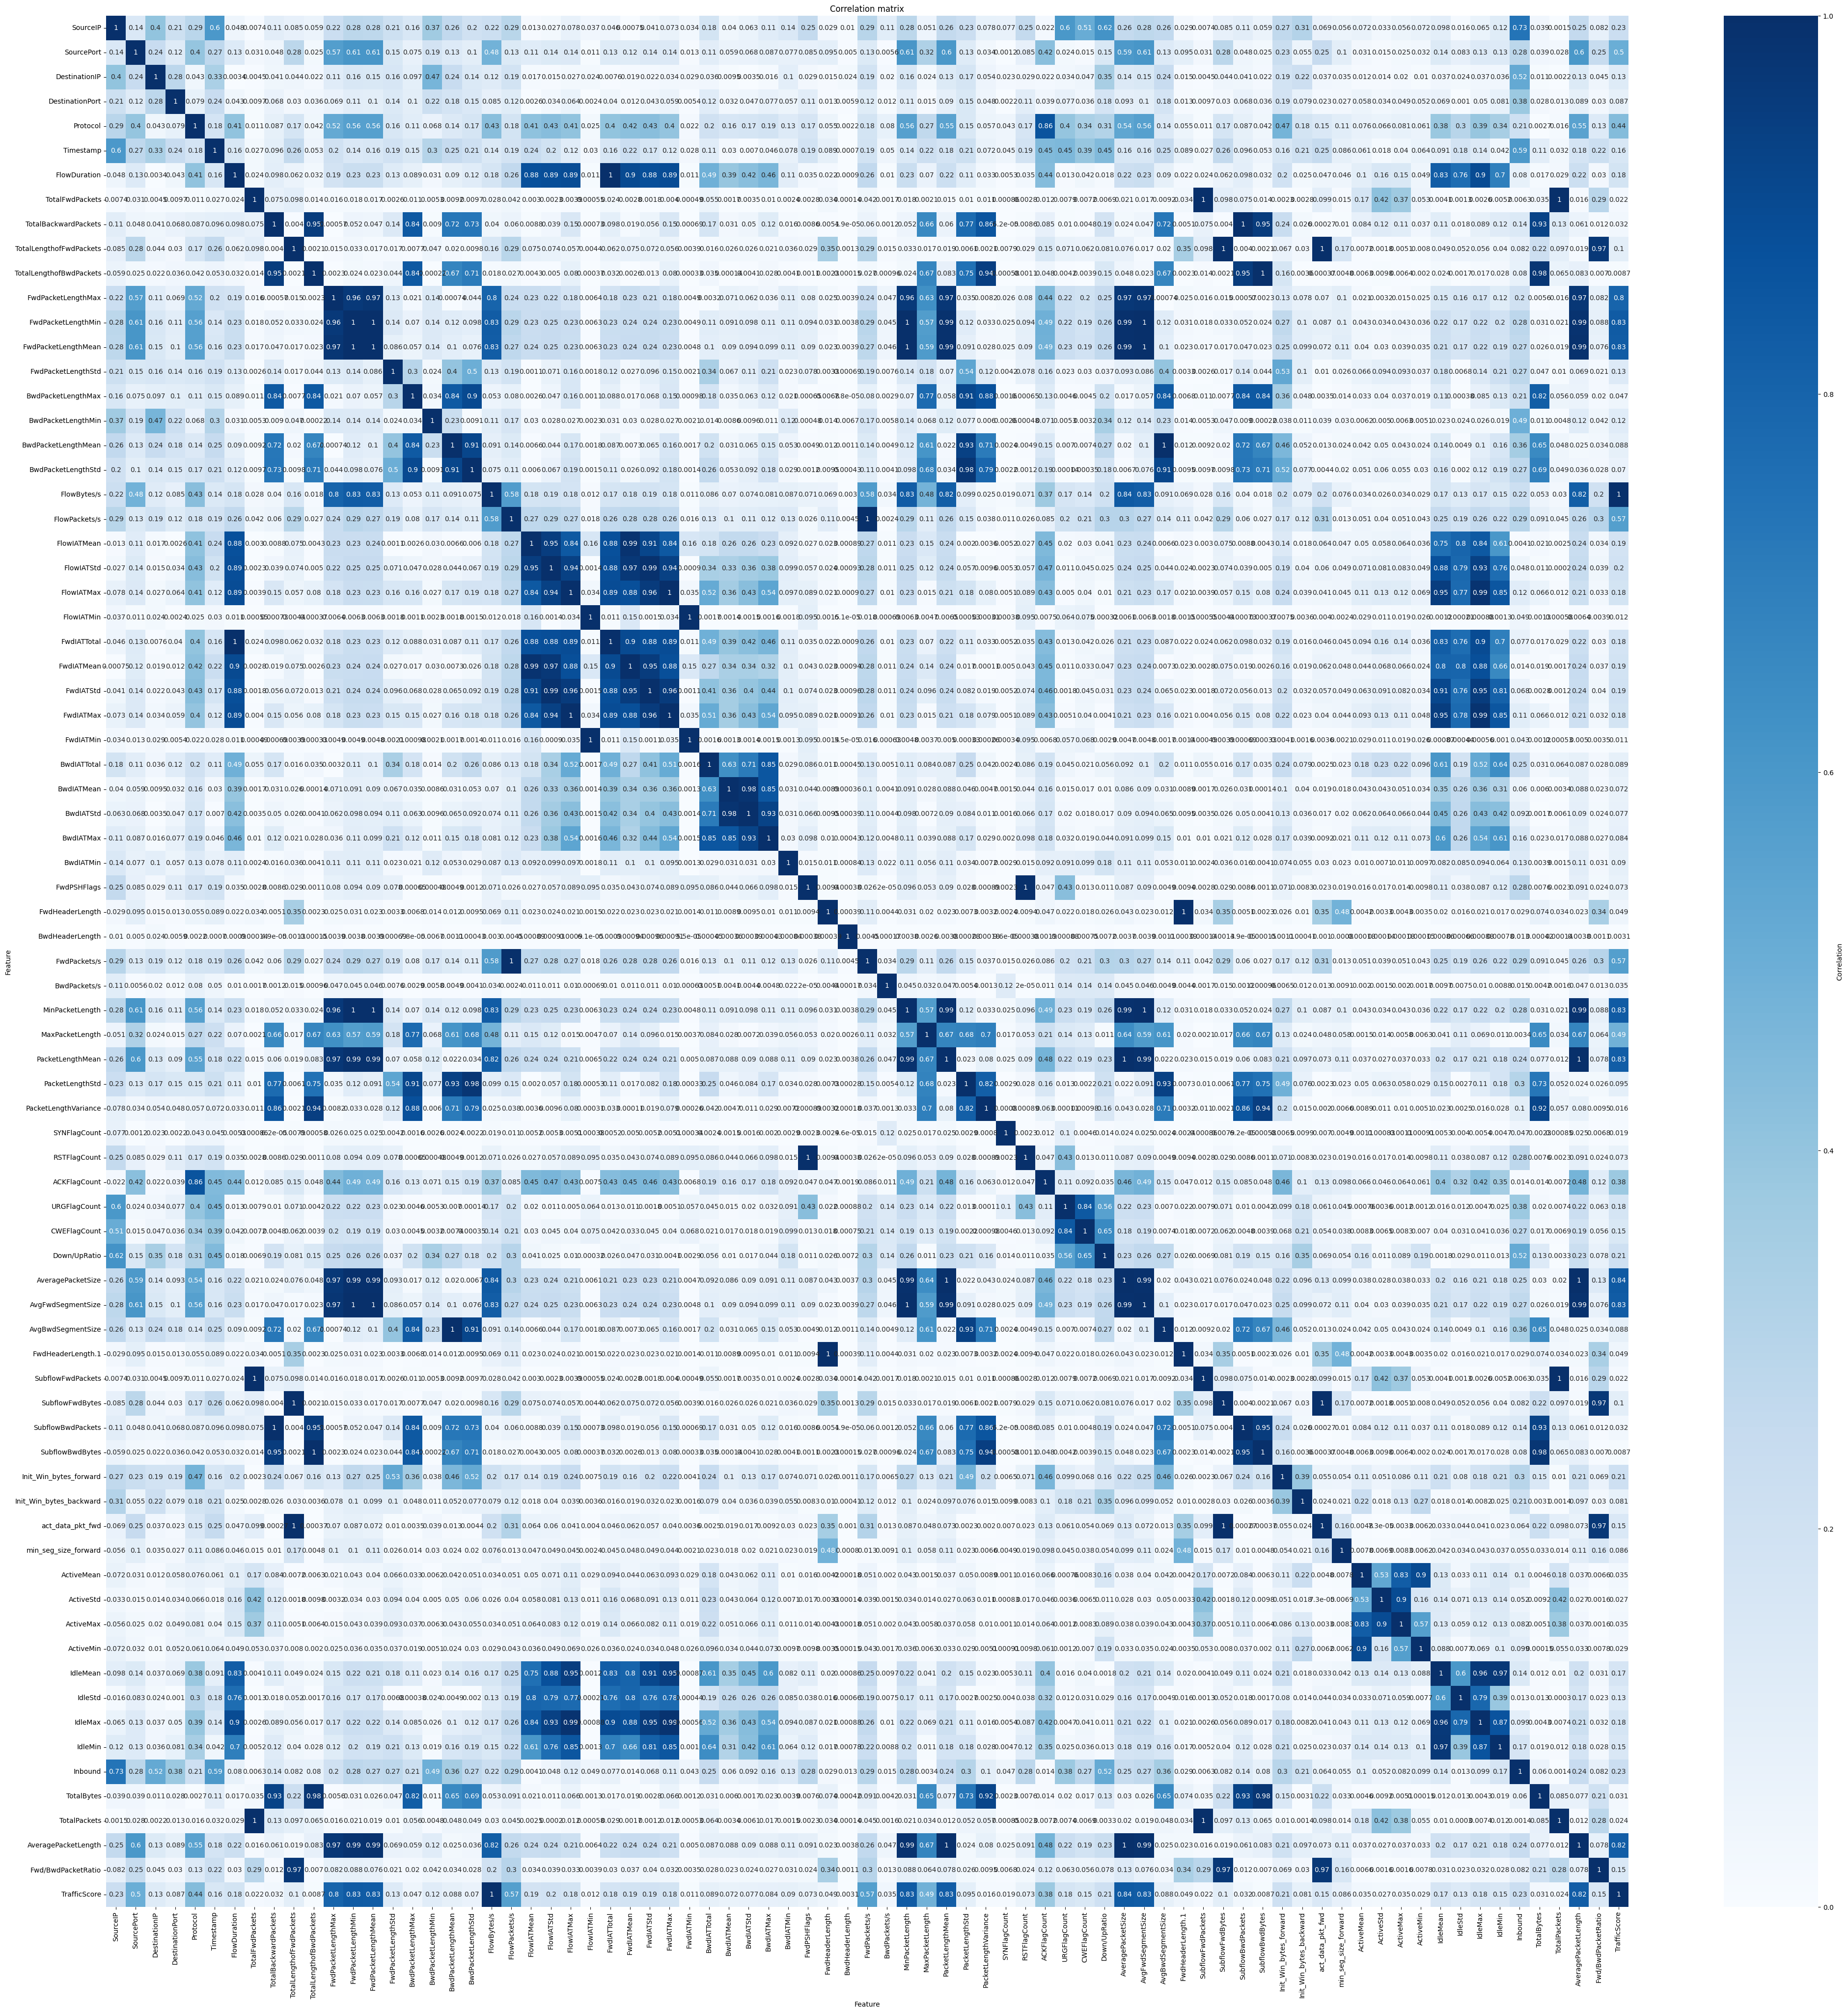

In [274]:
correlation_matrix = df_scale.corr().abs()

plt.figure(figsize=(50,50))
sns.heatmap(correlation_matrix, cmap='Blues', annot=True, vmin=.0, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.title('Correlation matrix')
plt.show()

In [275]:
# Extract features having a correlation > 0.8
c = correlation_matrix[correlation_matrix > 0.8]
s = c.unstack()
so = s.sort_values(ascending=False).reset_index()

# Get strongly correlatead features, removing pairs having correlation = 1 because of the diagonal, i.e., correlation between one feature and itself
so = so[(so[0].isnull()==False) & (so["level_0"] != so["level_1"])]
to_be_deleted = []
candidates = list(so["level_0"])

# Get the unique set of features to be deleted
# Notice that we discard one feature per time considering the case where a feature is strongly correlated with multiple features
subset_so = so
for candidate in candidates:
    if (candidate in list(subset_so["level_0"])): 
        to_be_deleted.append(candidate) # add the feature to the removed candidates
        subset_so = subset_so[(subset_so["level_0"] != candidate) & (subset_so["level_1"] != candidate)] # remove the rows that the removed feature is involved

print(len(to_be_deleted), 'features to be removed')

46 features to be removed


In [276]:
new_df = df_scale.copy()
new_df = new_df.drop(columns=to_be_deleted)
new_df

,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FwdPacketLengthMax,FwdPacketLengthStd,BwdPacketLengthMax,BwdPacketLengthMin,...,Down/UpRatio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,ActiveStd,IdleStd,IdleMin,Inbound,TotalPackets,Fwd/BwdPacketRatio
0,-0.294846,-0.996890,-0.156273,1.463534,0.560382,-0.981207,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.165384,1.710894
1,2.322551,-0.996890,-2.966318,1.463534,0.560382,-0.981205,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,-3.381206,-0.038977,-0.261778
2,-0.294846,-0.996890,-0.156273,0.770389,0.560382,-0.981198,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.386953,3.849685
3,-0.294846,-0.996890,-0.156273,-0.924976,0.560382,-0.981189,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.386953,3.849685
4,-0.294846,-0.996890,-0.156273,-0.139438,0.560382,-0.981176,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.386953,3.849685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,-0.294846,0.540571,-0.156273,1.589149,0.560382,0.942099,-0.408056,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.038977,-0.261778
64235,-0.294846,1.350236,-0.156273,-0.577568,0.560382,0.942099,-0.377323,0.521580,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.030372,-0.178718
64236,-0.294846,0.843239,-0.156273,1.670387,0.560382,0.942099,-0.408056,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.038977,-0.261778
64237,-0.294846,1.433360,-0.156273,-0.996433,0.560382,0.942099,-0.384152,0.501315,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.034674,-0.220248


### PCA

In [277]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(new_df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


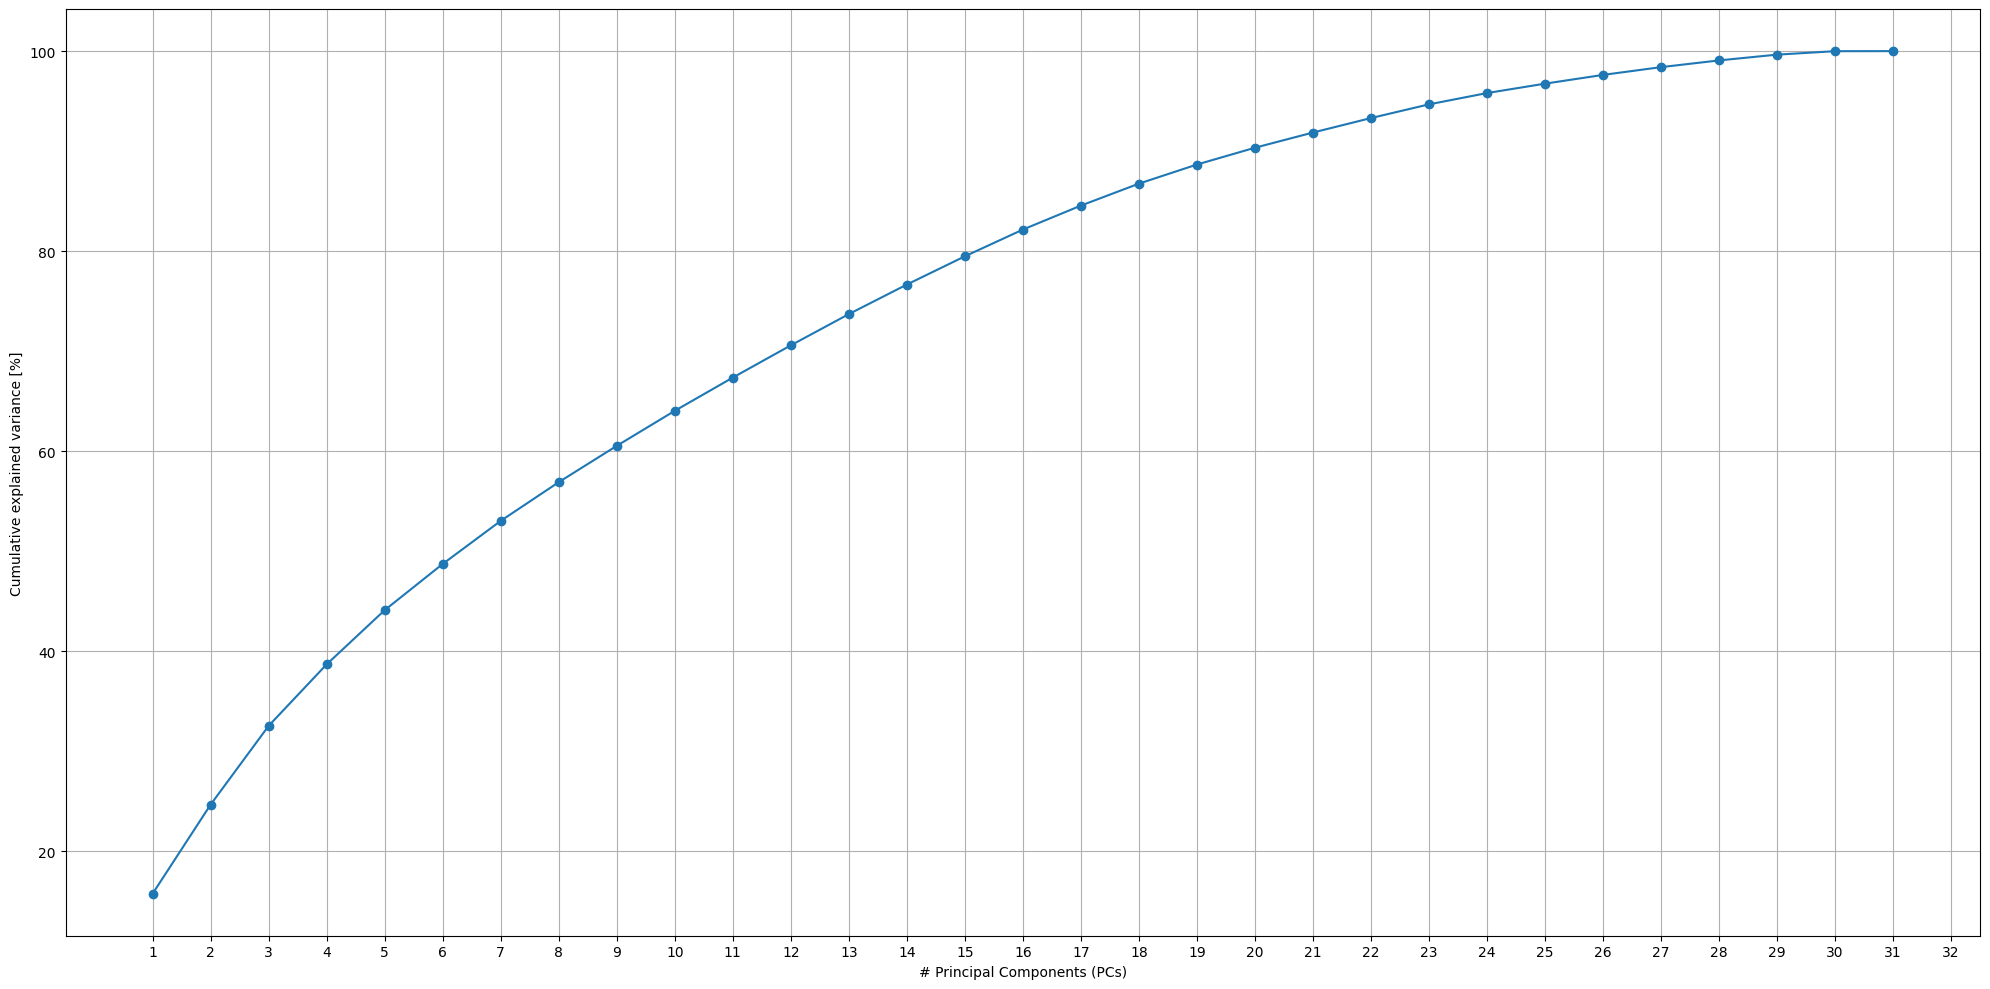

In [278]:
explained_variance = pca.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance)
perc_cumul_exp_var = cumul_exp_var * 100

plt.figure(figsize=(20, 10))
plt.plot(perc_cumul_exp_var, marker='o')
plt.xlabel('# Principal Components (PCs)')
plt.xticks([i for i in range(32)], [i for i in range(1,33)])
plt.ylabel('Cumulative explained variance [%]')
plt.grid()
plt.tight_layout()

perc_cumul_exp_var[19] = 89.49759008604823

this means that with 20 principal components the cumulative explained variance is nearly 90%

## 4. Characterize the new final feature matrix

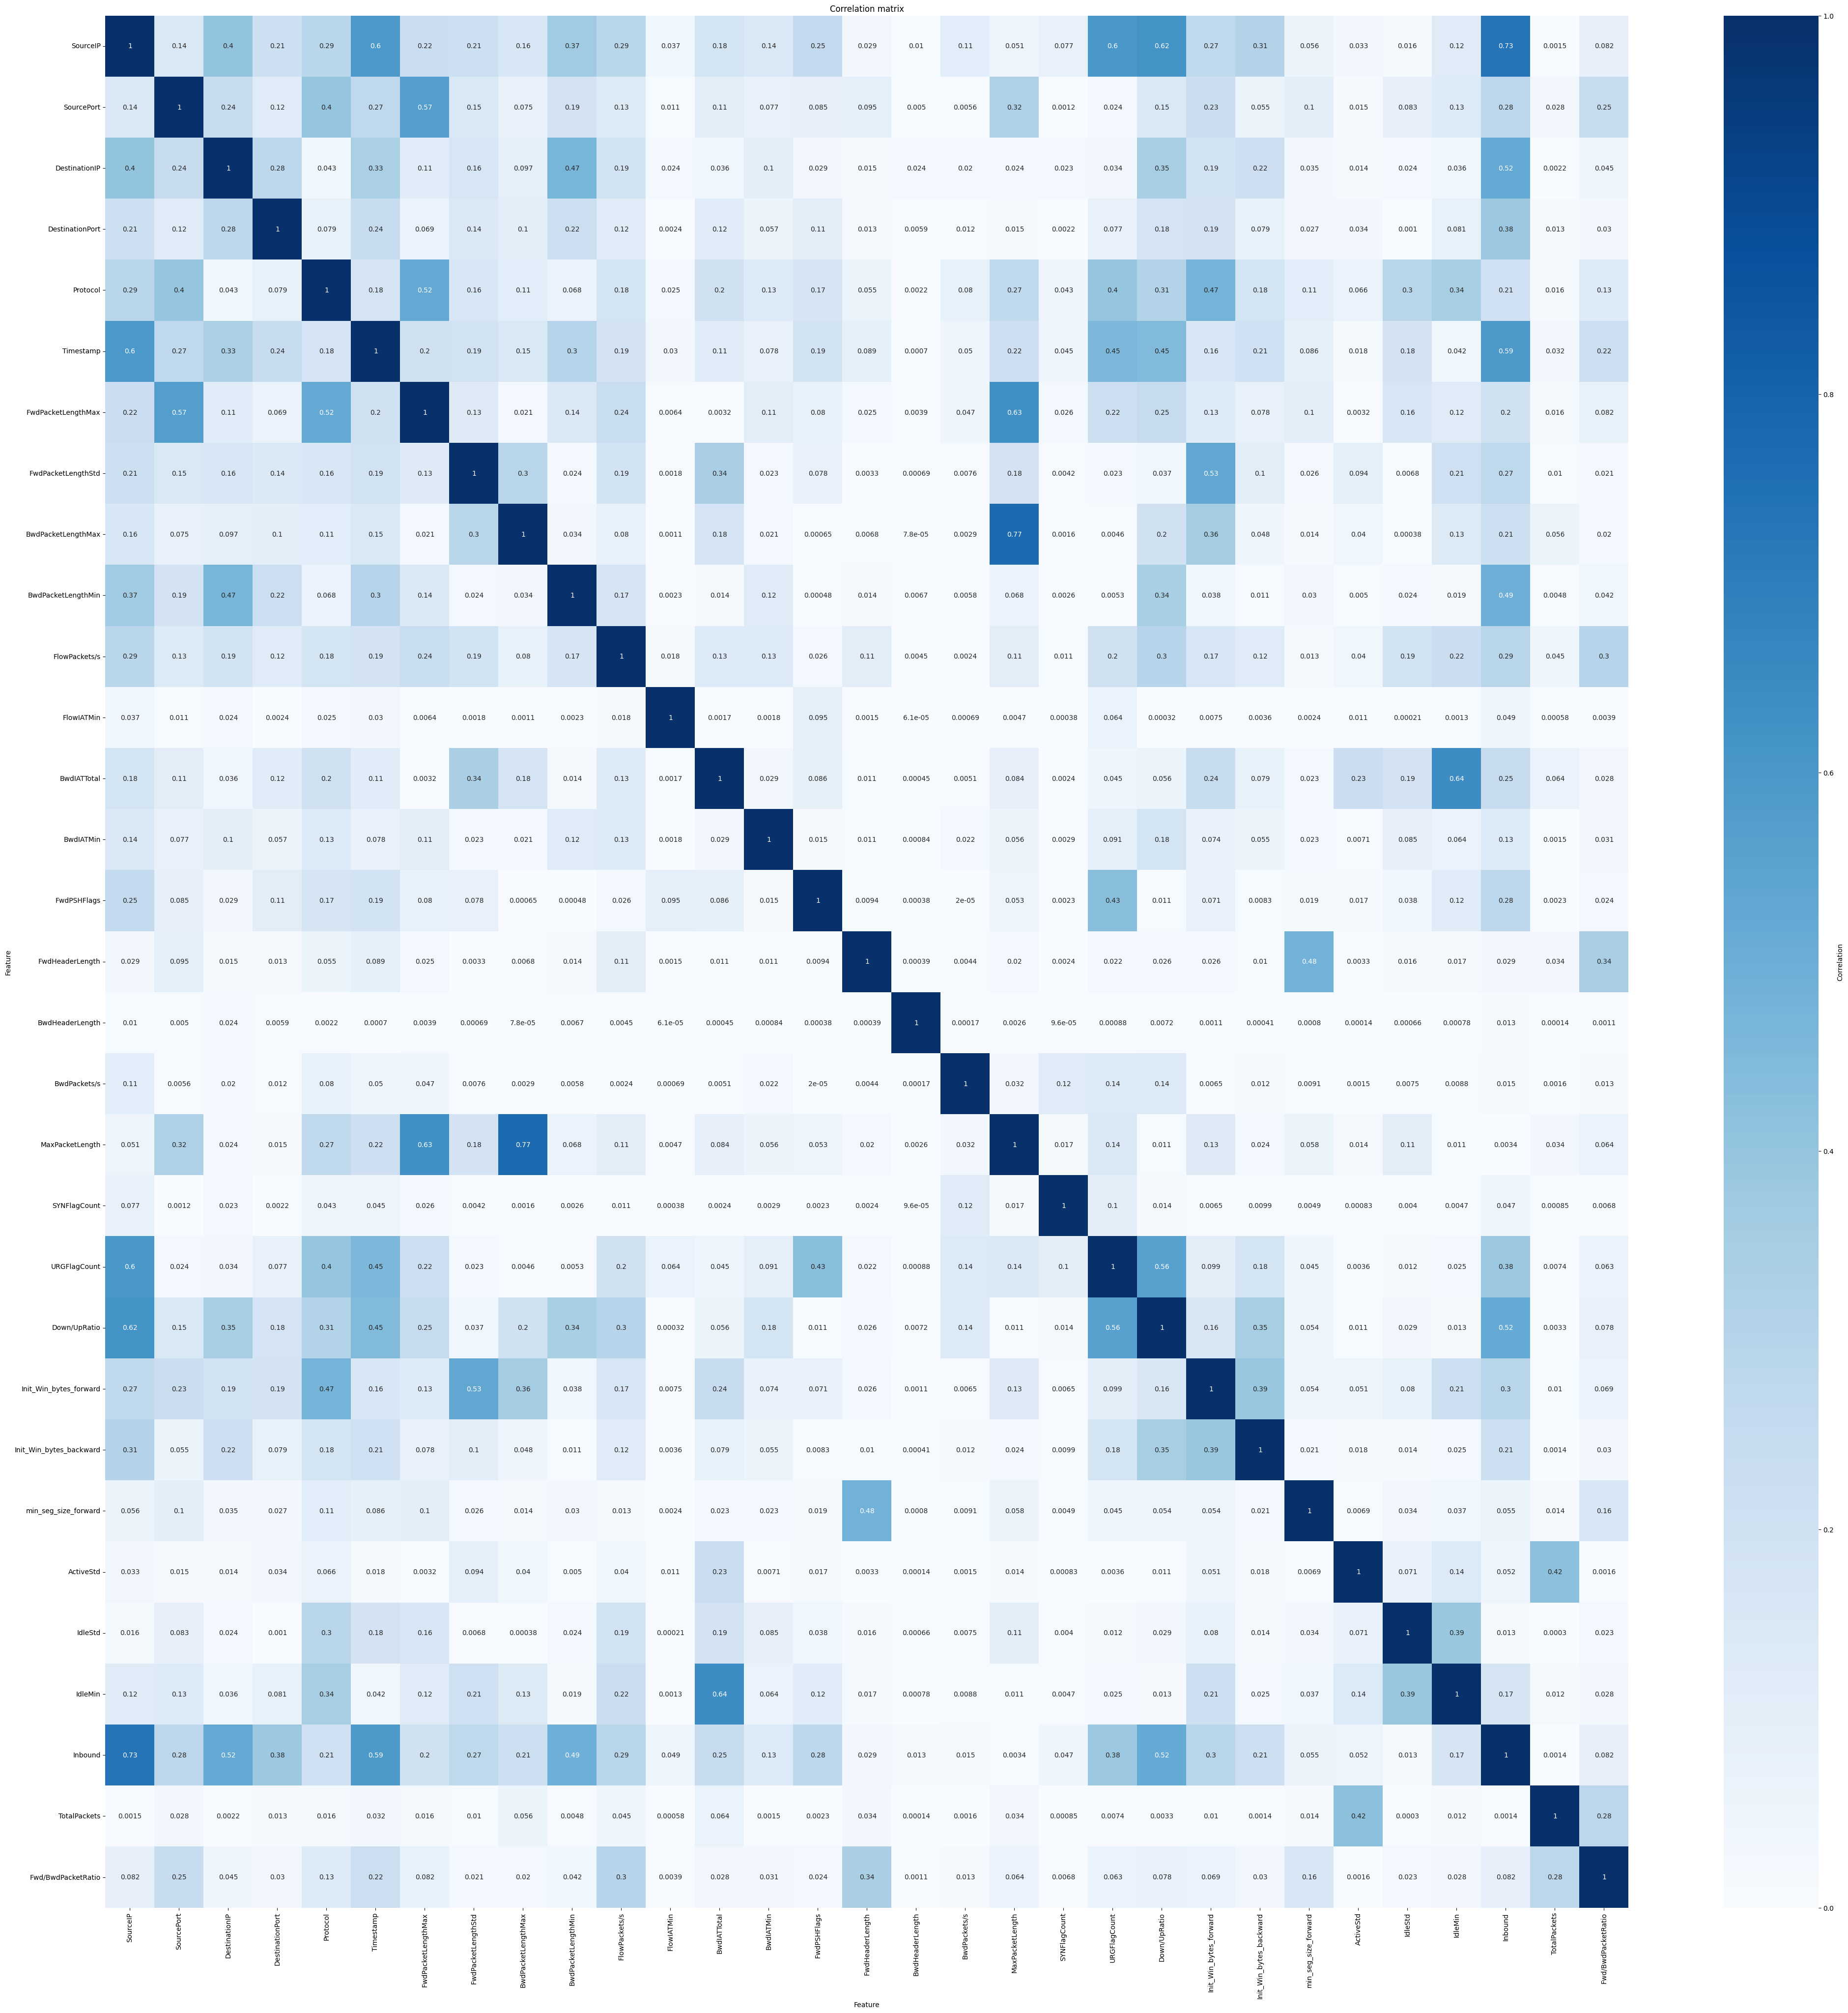

In [279]:
correlation_matrix = new_df.corr().abs()

plt.figure(figsize=(50,50))
sns.heatmap(correlation_matrix, cmap='Blues', annot=True, vmin=.0, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.title('Correlation matrix')
plt.show()

In [280]:
# producing plots regarding distributions of features (EPDF or ECDF)  ......

# Section 3

## 3a

In [281]:
pca_2D = PCA(n_components=2)
projection = pd.DataFrame(pca_2D.fit_transform(new_df), columns=["PC1","PC2"])


# Helper function to plot the clustering -- only 2 dimensione (if more, it will plot only the first two columns).
def plot_clustering(X, labels, centers=None, title="", subplot=None):

    # Plot in given subplot
    if subplot:
        plt.subplot(subplot)

    # Plot data with labels as color
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, s=5, cmap="viridis", alpha=0.7, label="Data points")

    # Plot centers if given
    if centers is not None:
        plt.scatter(
            centers[:, 0], centers[:, 1], c="red", s=150, alpha=0.9, label="Centers"
        )

    # Set title
    plt.title(title)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])

In [282]:
X_sample, y_sample = resample(new_df.values, label_df.values, n_samples=10000, random_state=42, replace=False)
#X_sample = new_df.values
y_sample = np.array(y_sample).ravel()

Xfull = new_df.values
y_full = label_df.values

print(X_sample.shape)
print(y_sample.shape)
display(y_sample)

(10000, 31)
(10000,)


array(['ddos_ldap', 'ddos_dns', 'ddos_tftp', ..., 'ddos_mssql',
       'ddos_udp', 'ddos_snmp'], shape=(10000,), dtype=object)

## 1 - Elbow method
### ALGO 1: KMEANS
Detect how many clusters

In [283]:
inertia = []
silhouette_km = []
ari_km = []
ri_km = []
k_range = range(2, 12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cl_km = kmeans.fit_predict(X_sample)
    
    inertia.append(kmeans.inertia_)
    silhouette_km.append(silhouette_score(X_sample, cl_km))
    ari_km.append(adjusted_rand_score(y_sample, cl_km))
    ri_km.append(rand_score(y_sample, cl_km))
    print(f'K={k}, Inertia={kmeans.inertia_}, Silhouette_Euclidean={silhouette_km[-1]}')

K=2, Inertia=240309.5194257728, Silhouette_Euclidean=0.3623981336498996
K=3, Inertia=215581.21911707512, Silhouette_Euclidean=0.5764052259978458
K=4, Inertia=196982.14022407355, Silhouette_Euclidean=0.23419101135504342
K=5, Inertia=177885.14693116627, Silhouette_Euclidean=0.23704364707442227
K=6, Inertia=165544.92807830859, Silhouette_Euclidean=0.24322745811879348
K=7, Inertia=152976.1632899178, Silhouette_Euclidean=0.24642273643672666
K=8, Inertia=143102.27989207284, Silhouette_Euclidean=0.27920940108309017
K=9, Inertia=129772.63795532558, Silhouette_Euclidean=0.28254733286352485
K=10, Inertia=122281.92401909066, Silhouette_Euclidean=0.27871022335005347
K=11, Inertia=112261.94345160521, Silhouette_Euclidean=0.2976378280101537


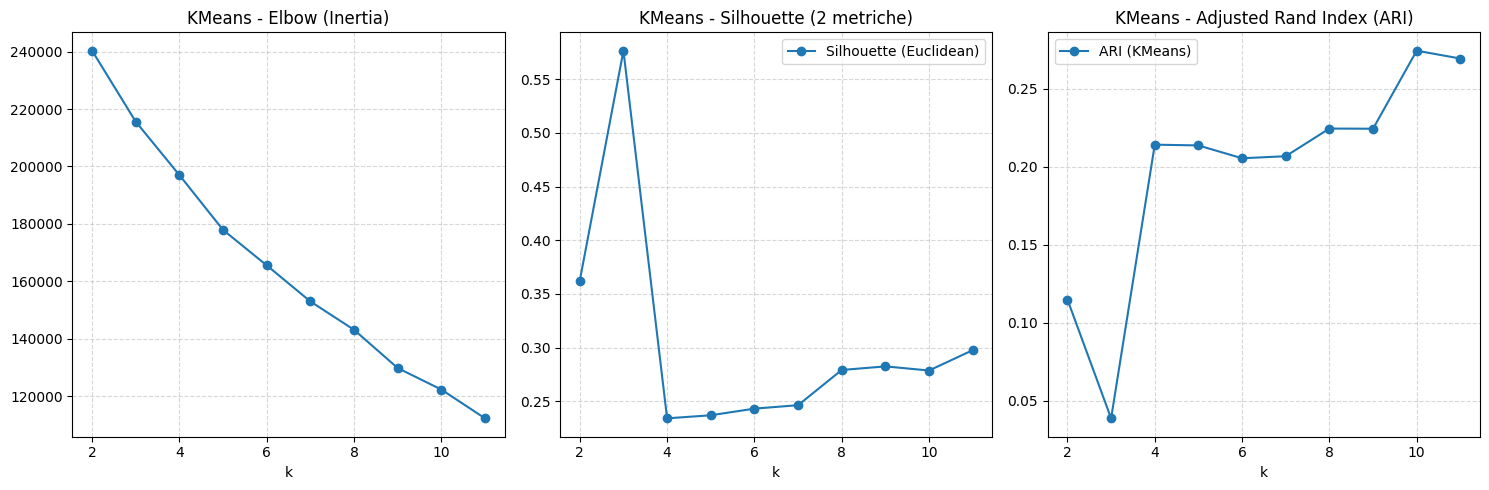

Best k for KMeans (by Silhouette-Euclidean): 3


In [284]:

fig, axs = plt.subplots(1,3, figsize=(15, 5))

axs[0].plot(k_range, inertia, marker="o")
axs[0].set_title("KMeans - Elbow (Inertia)")
axs[0].set_xlabel("k"); axs[0].grid(True, linestyle="--", alpha=0.5)

axs[1].plot(k_range, silhouette_km, marker="o", label="Silhouette (Euclidean)")
#axs[1].plot(k_range, silhouette_mah, marker="o", label="Silhouette (Mahalanobis)")
axs[1].set_title("KMeans - Silhouette (2 metriche)")
axs[1].set_xlabel("k"); axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].legend()

axs[2].plot(k_range, ari_km, marker="o", label="ARI (KMeans)")
axs[2].set_title("KMeans - Adjusted Rand Index (ARI)")
axs[2].set_xlabel("k"); axs[2].grid(True, linestyle="--", alpha=0.5)
axs[2].legend()

plt.tight_layout()
plt.show()

best_k_km = k_range[int(np.argmax(silhouette_km))]
print("Best k for KMeans (by Silhouette-Euclidean):", best_k_km)

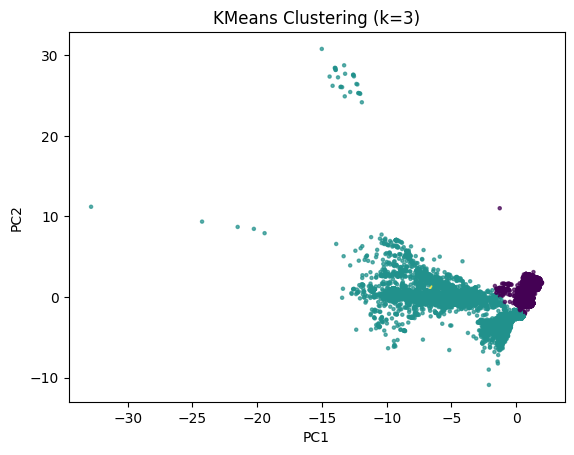

In [285]:
#running KMeans with the best k found
kmeans = KMeans(n_clusters=best_k_km)
cl_km = kmeans.fit_predict(new_df)
plot_clustering(projection, cl_km, None, title=f'KMeans Clustering (k={best_k_km})')

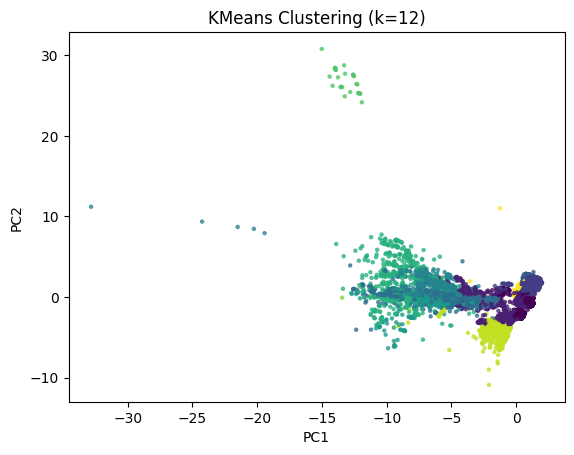

In [286]:
kmeans_true = KMeans(n_clusters=12)
cl_true = kmeans_true.fit(new_df)
plot_clustering(projection, cl_true.labels_, None, title='KMeans Clustering (k=12)')

### ALGO 2: GMM

In [287]:
k_range = range(2, 12)
silhouette_gmm = []
ari_gmm = []
ri_gmm = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cl_gmm = gmm.fit_predict(X_sample)
    
    silhouette_gmm.append(silhouette_score(X_sample, cl_gmm, metric="euclidean"))
    ari_gmm.append(adjusted_rand_score(y_sample, cl_gmm))
    ri_gmm.append(rand_score(y_sample, cl_gmm))
    print(f'K={k}, Silhouette_Euclidean={silhouette_gmm[-1]}')

K=2, Silhouette_Euclidean=0.4869755244017944
K=3, Silhouette_Euclidean=0.5216761944280007
K=4, Silhouette_Euclidean=0.30131214895884384
K=5, Silhouette_Euclidean=0.30419506253946055
K=6, Silhouette_Euclidean=0.3140035787418728
K=7, Silhouette_Euclidean=0.33242397027906206
K=8, Silhouette_Euclidean=0.29808723955217403
K=9, Silhouette_Euclidean=0.30215875035752104
K=10, Silhouette_Euclidean=0.2745641712264493
K=11, Silhouette_Euclidean=0.2936879713716656


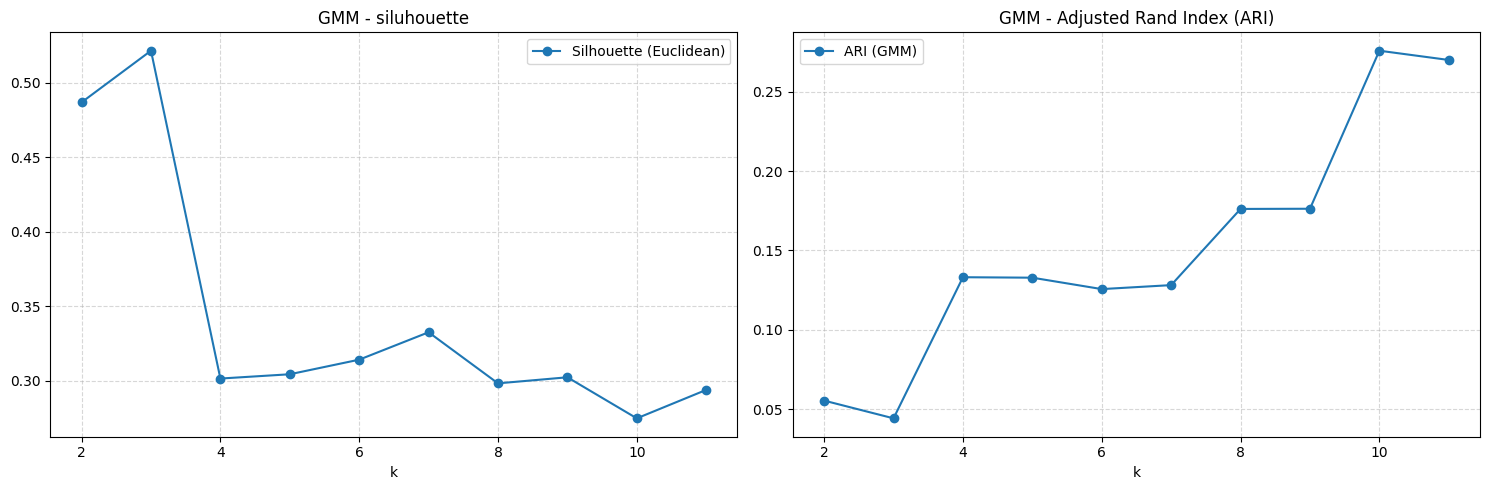

Best k for GMM (by Silhouette-Euclidean): 3


In [288]:
fig, axs = plt.subplots(1,2, figsize=(15, 5))

axs[0].plot(k_range, silhouette_gmm, marker="o", label="Silhouette (Euclidean)")
axs[0].set_title("GMM - siluhouette")
axs[0].set_xlabel("k"); axs[0].grid(True, linestyle="--", alpha=0.5)
axs[0].legend()

axs[1].plot(k_range, ari_gmm, marker="o", label="ARI (GMM)")
axs[1].set_title("GMM - Adjusted Rand Index (ARI)")
axs[1].set_xlabel("k"); axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].legend()
plt.tight_layout()
plt.show()

best_k_gmm = k_range[int(np.argmax(silhouette_gmm))]
print("Best k for GMM (by Silhouette-Euclidean):", best_k_gmm)

In [289]:
gmm = GaussianMixture(n_components=best_k_gmm)
cl = gmm.fit(new_df)

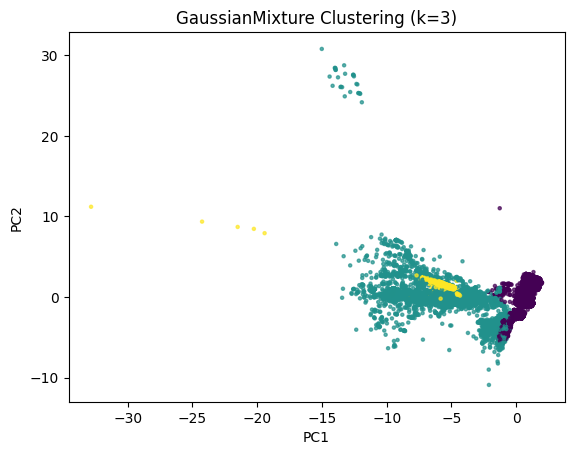

In [290]:
plot_clustering(projection, cl.predict(new_df), None, title=f'GaussianMixture Clustering (k={best_k_gmm})')

In [291]:
gmm_true = GaussianMixture(n_components=12)
gmm_true.fit(new_df)

,n_components,12
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


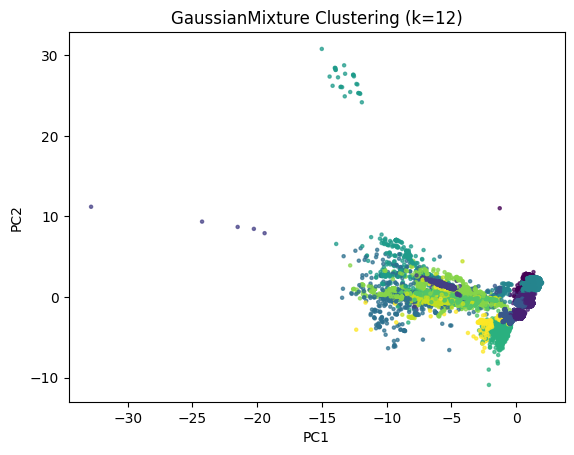

In [292]:
plot_clustering(projection, gmm_true.predict(new_df), None, title='GaussianMixture Clustering (k=12)')

## 3 - Performance Tuning.
### A. Find the best hyper-parameters, if any.

#### Tuning Kmeans

In [293]:
k_candidates = range(max(2,best_k_km-2 ), best_k_km+3)
init_candidates = ["k-means++", "random"]
n_init_candidates = [10, 20, 50]

rows_km = []
for k in k_candidates:
    for init in init_candidates:
        for n_init in n_init_candidates:
            km = KMeans(
                n_clusters=k,
                init=init,
                n_init=n_init,
                random_state=r
            )
            km.fit(X_sample)
            #m = eval_clustering(X_sample, km.labels_, VI)
            rows_km.append({
                "model": "KMeans",
                "k": k,
                "init": init,
                "n_init": n_init,
                "inertia": km.inertia_,
                "sil_euc": silhouette_score(X_sample, km.labels_, metric="euclidean"),
                #**m
            })

In [294]:
km_tuning = pd.DataFrame(rows_km).sort_values(["sil_euc"], ascending=[False])
km_tuning.head(10)

,model,k,init,n_init,inertia,sil_euc
0,KMeans,2,k-means++,10,227159.679992,0.576335
1,KMeans,2,k-means++,20,227159.679992,0.576335
2,KMeans,2,k-means++,50,227159.679992,0.576335
3,KMeans,2,random,10,227159.722942,0.576335
4,KMeans,2,random,20,227159.722942,0.576335
5,KMeans,2,random,50,227159.722942,0.576335
7,KMeans,3,k-means++,20,207997.074676,0.571470
8,KMeans,3,k-means++,50,207997.074676,0.571470
18,KMeans,5,k-means++,10,174425.290053,0.240035
20,KMeans,5,k-means++,50,174425.290053,0.240035


##### Best final fit

In [295]:
best_row_km = km_tuning.iloc[0]
best_km = KMeans(
    n_clusters=int(best_row_km["k"]),
    init=best_row_km["init"],
    n_init=int(best_row_km["n_init"]),
    random_state=42
).fit(new_df)

labels_km_full = best_km.labels_

#### Tuning GMM

In [296]:
cov_types = ["full", "tied", "diag", "spherical"]
k_candidates = range(max(2,best_k_gmm-2 ), best_k_gmm+3)

rows = []
for k in k_candidates:
    for cov_t in cov_types:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_t,
            init_params="kmeans",
            random_state=42
        )
        gmm.fit(X_sample)
        lab = gmm.predict(X_sample)
        #m = eval_clustering(X_sample, lab, VI)
        rows.append({
            "model": "GMM",
            "k": k,
            "covariance_type": cov_t,
            "sil_euc": silhouette_score(X_sample, lab, metric="euclidean"),
        })



In [297]:
gmm_tuning = pd.DataFrame(rows)

gmm_tuning_sorted = gmm_tuning.sort_values(["sil_euc"], ascending=[False])
gmm_tuning_sorted.head(10)

,model,k,covariance_type,sil_euc
5,GMM,3,tied,0.571820
4,GMM,3,full,0.521676
6,GMM,3,diag,0.498337
0,GMM,2,full,0.486976
7,GMM,3,spherical,0.415360
3,GMM,2,spherical,0.415336
1,GMM,2,tied,0.357690
2,GMM,2,diag,0.356665
14,GMM,5,diag,0.304342
12,GMM,5,full,0.304195


In [298]:
best_row_gmm = gmm_tuning_sorted.iloc[0]
best_gmm = GaussianMixture(
    n_components=int(best_row_gmm["k"]),
    covariance_type=best_row_gmm["covariance_type"],
    init_params="kmeans",
    random_state=42
).fit(new_df)

labels_gmm_full = best_gmm.predict(new_df)

In [299]:
display(best_gmm)
print(best_gmm.score(new_df))

,n_components,3
,covariance_type,'tied'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


-33.551075946556644


### B Evaluate clusters

In [300]:
def eval_clustering(X, labels, y_true=None):
    ari, ri = None, None
    if y_true is not None:
            ari = adjusted_rand_score(y_true, labels),
            ri = rand_score(y_true, labels)
    return {
        "k": len(np.unique(labels)),
        "sil_euc": silhouette_score(X, labels, metric="euclidean"),
        "ARI": ari,
        "RI": ri,
    }

In [301]:
y_true = labels["IntLabel"].values  # se disponibile

rep_km = eval_clustering(Xfull, labels_km_full, y_true=y_true)
rep_gmm = eval_clustering(Xfull, labels_gmm_full, y_true=y_true)

print("KMeans:", rep_km)
print("GMM:  ", rep_gmm)

KMeans: {'k': 2, 'sil_euc': 0.5825125779491719, 'ARI': (0.04065849807952815,), 'RI': 0.27015281252610374}
GMM:   {'k': 3, 'sil_euc': 0.38167430779136735, 'ARI': (0.06911582161136086,), 'RI': 0.37564173870784806}


### C Visualization (PCA 2D)

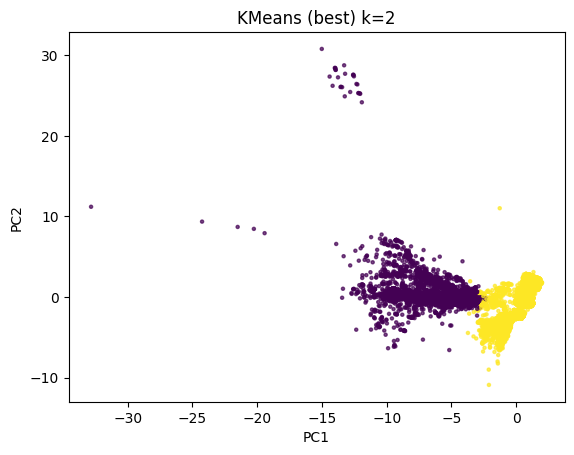

In [302]:
plot_clustering(projection, labels_km_full, None, title=f'KMeans (best) k={len(np.unique(labels_km_full))}')

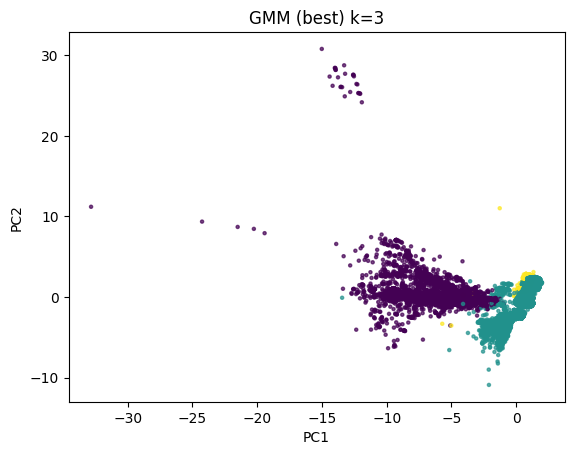

In [303]:
plot_clustering(projection, labels_gmm_full, None, title=f'GMM (best) k={len(np.unique(labels_gmm_full))}')

## 4 - Coarse analysis
### ECDF of number flows per cluster

Text(0, 0.5, 'Cumulative Probability')

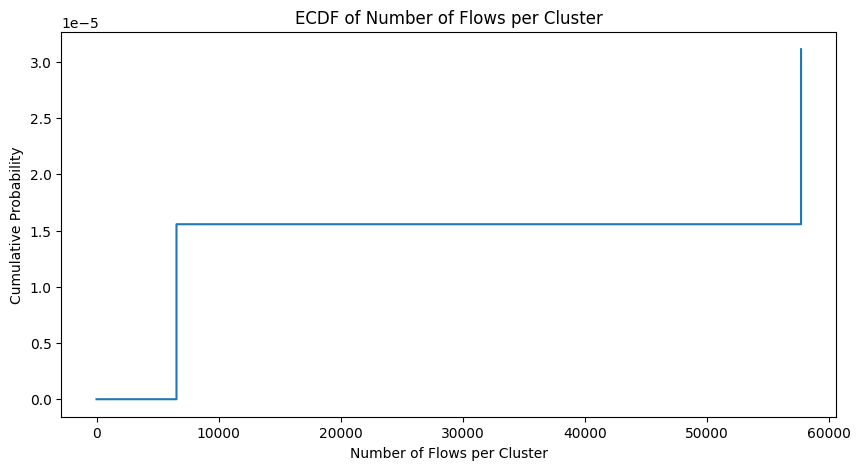

In [304]:
flow_per_cluster = [np.sum(labels_km_full == i) for i in np.unique(labels_km_full)]

ecdf = np.cumsum(np.bincount(flow_per_cluster)) / len(labels_km_full)

plt.figure(figsize=(10, 5))
plt.step(range(len(ecdf)), ecdf, where='post')
plt.title('ECDF of Number of Flows per Cluster')
plt.xlabel('Number of Flows per Cluster')
plt.ylabel('Cumulative Probability')


Text(0, 0.5, 'Cumulative Probability')

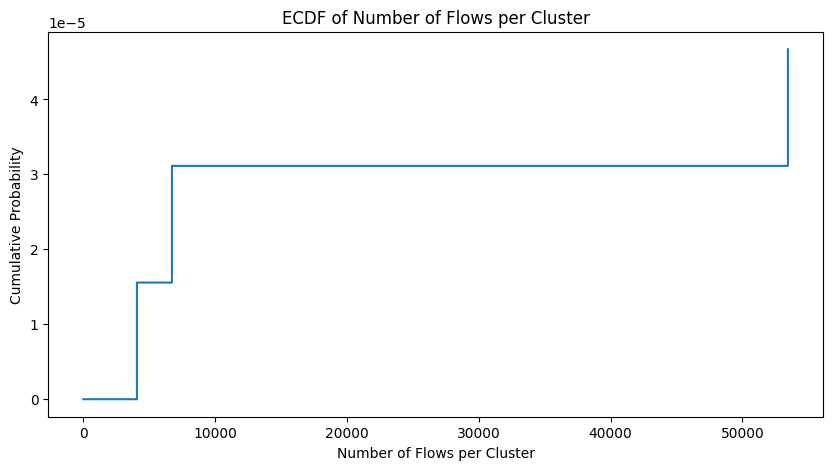

In [305]:
flow_per_cluster = [np.sum(labels_gmm_full == i) for i in np.unique(labels_gmm_full)]

ecdf = np.cumsum(np.bincount(flow_per_cluster)) / len(labels_gmm_full)

plt.figure(figsize=(10, 5))
plt.step(range(len(ecdf)), ecdf, where='post')
plt.title('ECDF of Number of Flows per Cluster')
plt.xlabel('Number of Flows per Cluster')
plt.ylabel('Cumulative Probability')


In [306]:
def silhouette_plot(X, PCA, labels, n_clusters, silhouette, silhouette_vals):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    #ax1.set_xlim([-1, 1])
    #ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
    ax2.scatter(PCA.iloc[:, 0], PCA.iloc[:, 1], c=colors, s=5, alpha=0.7,marker=".")
    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")


In [307]:
#n_clusters = len(np.unique(labels_km_full))

silhouette_vals_km = silhouette_samples(Xfull, labels_km_full, metric="euclidean")
silhouette_vals_gmm = silhouette_samples(Xfull, labels_gmm_full, metric="euclidean")

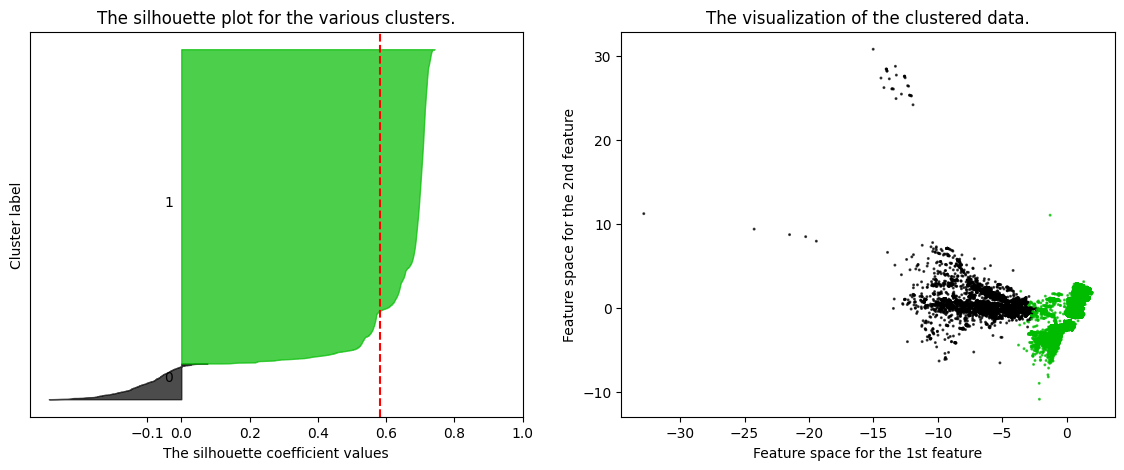

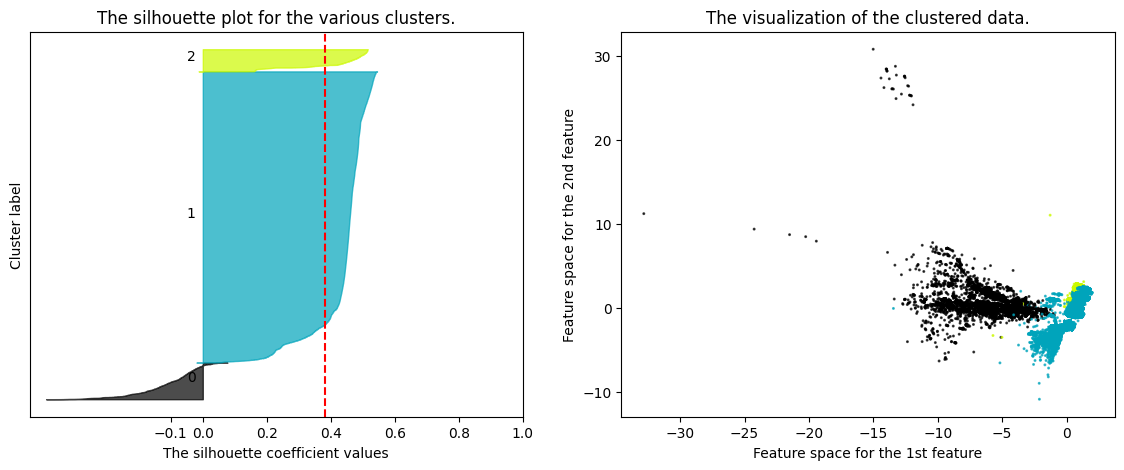

In [308]:

silhouette_plot(Xfull, projection, labels_km_full, len(np.unique(labels_km_full)), rep_km['sil_euc'], silhouette_vals_km)
silhouette_plot(Xfull, projection, labels_gmm_full, len(np.unique(labels_gmm_full)), rep_gmm['sil_euc'], silhouette_vals_gmm)

# SECTION 4
## 4.1 - Cluster Distribution of Traffic Types.

In [309]:
new_df

,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FwdPacketLengthMax,FwdPacketLengthStd,BwdPacketLengthMax,BwdPacketLengthMin,...,Down/UpRatio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,ActiveStd,IdleStd,IdleMin,Inbound,TotalPackets,Fwd/BwdPacketRatio
0,-0.294846,-0.996890,-0.156273,1.463534,0.560382,-0.981207,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.165384,1.710894
1,2.322551,-0.996890,-2.966318,1.463534,0.560382,-0.981205,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,-3.381206,-0.038977,-0.261778
2,-0.294846,-0.996890,-0.156273,0.770389,0.560382,-0.981198,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.386953,3.849685
3,-0.294846,-0.996890,-0.156273,-0.924976,0.560382,-0.981189,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.386953,3.849685
4,-0.294846,-0.996890,-0.156273,-0.139438,0.560382,-0.981176,-0.297075,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,0.386953,3.849685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,-0.294846,0.540571,-0.156273,1.589149,0.560382,0.942099,-0.408056,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.038977,-0.261778
64235,-0.294846,1.350236,-0.156273,-0.577568,0.560382,0.942099,-0.377323,0.521580,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.030372,-0.178718
64236,-0.294846,0.843239,-0.156273,1.670387,0.560382,0.942099,-0.408056,-0.172277,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.038977,-0.261778
64237,-0.294846,1.433360,-0.156273,-0.996433,0.560382,0.942099,-0.384152,0.501315,-0.069596,-0.146261,...,-0.265523,-0.266314,-0.102881,0.202023,-0.034259,-0.165955,-0.194882,0.295752,-0.034674,-0.220248


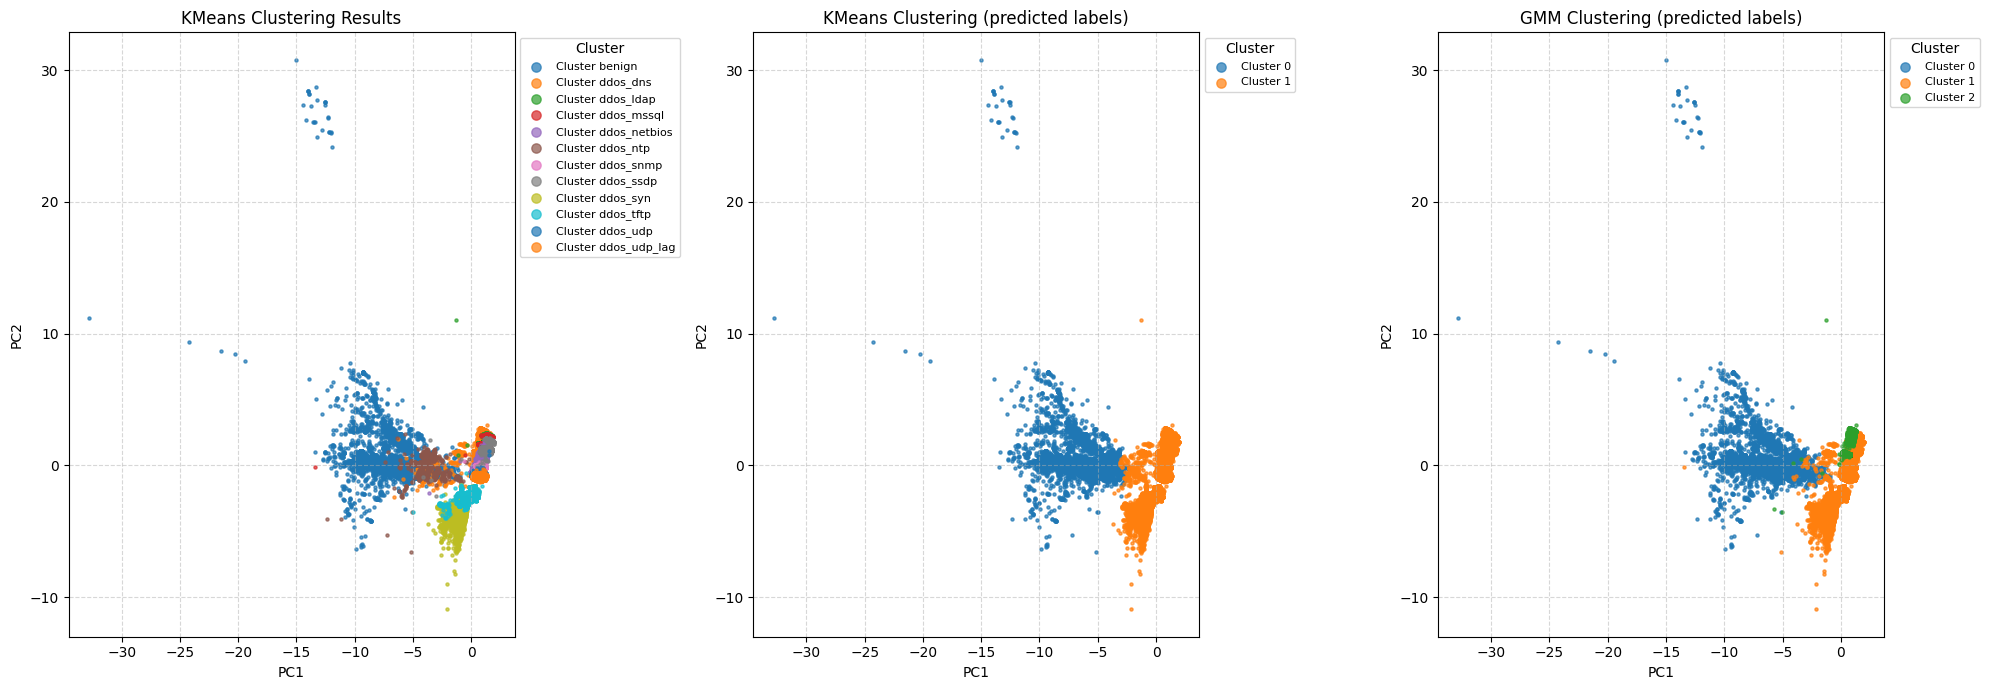

In [310]:
#best_km

fig, axs = plt.subplots(1, 3, figsize=(20, 7))

for l in np.unique(df['label']):
    p = projection[df['label'] == l]
    axs[0].scatter(p['PC1'], p['PC2'], s=5, alpha=0.7, label=f'Cluster {l}')

axs[0].set_title('KMeans Clustering Results')
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(title="Cluster", markerscale=3, bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)  # <-- legenda

for c in np.unique(labels_km_full):
    p = projection[labels_km_full == c]
    axs[1].scatter(p['PC1'], p['PC2'], s=5, alpha=0.7, label=f'Cluster {c}')


axs[1].set_title('KMeans Clustering (predicted labels)')
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(title="Cluster", markerscale=3, bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)  # <-- legenda

for c in np.unique(labels_gmm_full):
    p = projection[labels_gmm_full == c]
    axs[2].scatter(p['PC1'], p['PC2'], s=5, alpha=0.7, label=f'Cluster {c}')

axs[2].set_title('GMM Clustering (predicted labels)')
axs[2].set_xlabel('PC1')
axs[2].set_ylabel('PC2')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend(title="Cluster", markerscale=3, bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)  # <-- legenda

plt.tight_layout()
plt.show()
    

Contingency table

In [311]:
def ecdf(values):
    x = np.sort(np.asarray(values))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def cluster_distribution(y_true, labels, title_prefix=""):
    ct = pd.crosstab(labels, y_true)  # righe=cluster, colonne=classi
    ct_row_pct = ct.div(ct.sum(axis=1), axis=0).fillna(0)
    ct_col_pct = ct.div(ct.sum(axis=0), axis=1).fillna(0)

    # --- Heatmap (percentuale per cluster) ---
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    im = ax.imshow(ct_row_pct.values, aspect="auto")  # no seaborn: semplice
    ax.set_title(f"{title_prefix} Cluster composition (row-normalized)")
    ax.set_xlabel("GT class")
    ax.set_ylabel("Cluster id")
    ax.set_xticks(np.arange(ct_row_pct.shape[1]))
    ax.set_xticklabels(ct_row_pct.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(ct_row_pct.shape[0]))
    ax.set_yticklabels(ct_row_pct.index)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fraction within cluster")
    plt.tight_layout()
    plt.show()


    cd_df = pd.DataFrame(ct_col_pct)

    df_cumulativo = cd_df.cumsum()

    plt.figure(figsize=(7, 4))

    fig, axs = plt.subplots(4, 3, figsize=(10, 7), sharex=True, sharey=True)
    for i, ax in enumerate(axs.flat):
        ax.step(cd_df.index, df_cumulativo.iloc[:, i], where="post", marker='o',)
        ax.set_title(f"Class: {cd_df.columns[i]}")
        ax.set_ylabel("fraction within class")
        ax.set_xticks(np.arange(0, len(cd_df), 1))
        ax.grid(True, alpha=0.3)
        ax.set_yticks(np.arange(-0.2, 1.4, 0.2))
        ax.set_xticks(np.arange(0, len(cd_df), 1))
        ax.set_ylabel("fraction within class")
        ax.set_title(f"class {cd_df.columns[i]}")
    
    plt.tight_layout()
    plt.show()


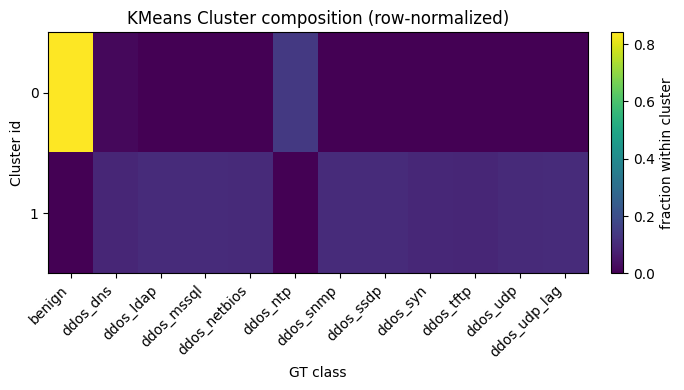

<Figure size 700x400 with 0 Axes>

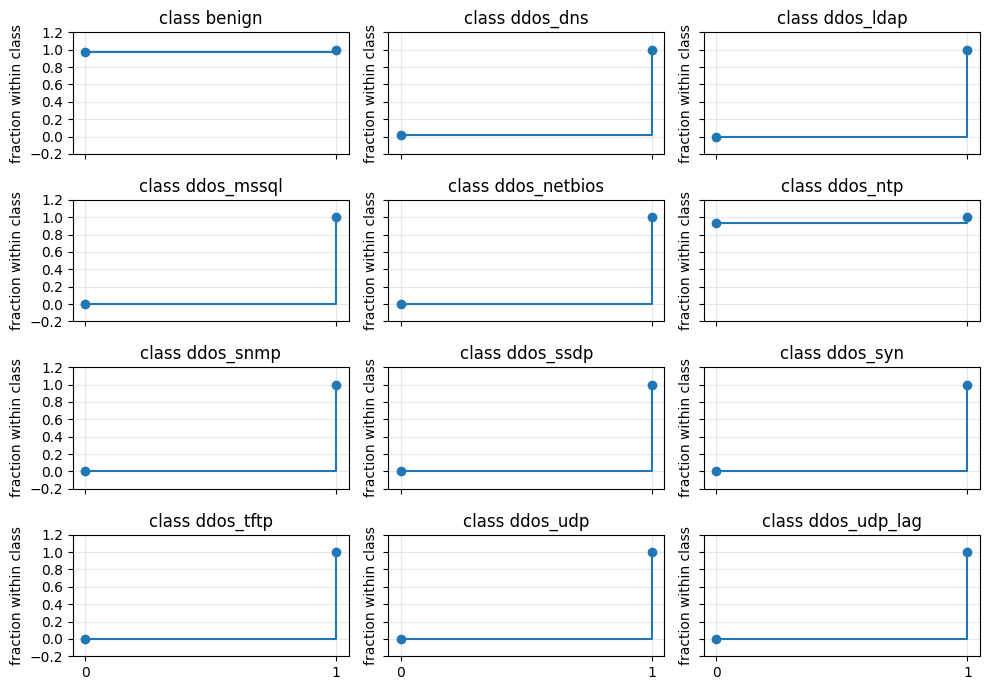

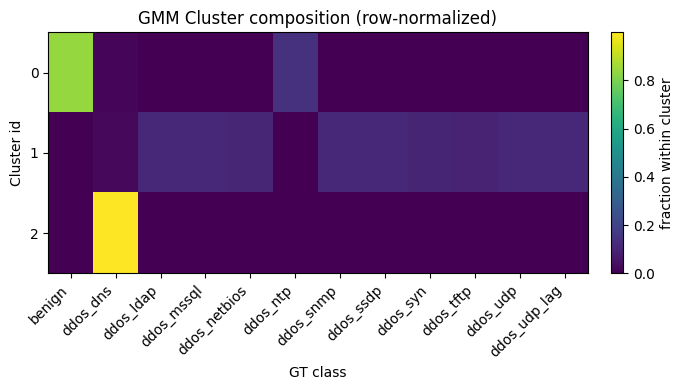

<Figure size 700x400 with 0 Axes>

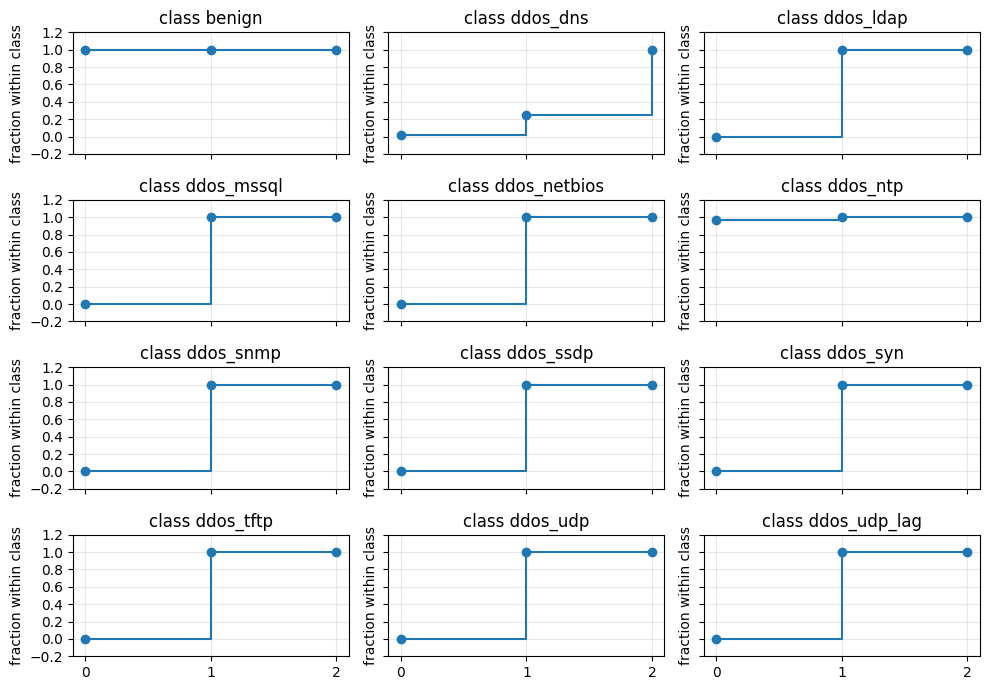

In [312]:
cluster_distribution(label_df['label'], labels_km_full, title_prefix="KMeans")
cluster_distribution(label_df['label'], labels_gmm_full, title_prefix="GMM")

## 4.2.a - Feature Importance Analysis.

In [313]:
def explain_clusters_with_permutation(X, cluster_labels, title="", top_n=15):
    y = pd.Series(cluster_labels, index=X.index, name="cluster")

    # split (stratified so each cluster stays represented)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # surrogate model to predict the cluster id
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    #t0 = time.perf_counter()
    rf.fit(X_tr, y_tr)
    #fit_time = time.perf_counter() - t0

    pred = rf.predict(X_te)
    acc = accuracy_score(y_te, pred)

    print(f"\n--- {title} ---")
    print("Surrogate RF accuracy (predict cluster id):", round(acc, 4))
    #print("Training time (s):", round(fit_time, 3))

    # permutation importance (accuracy drop)
    #t1 = time.perf_counter()
    perm = permutation_importance(
        rf, X_te, y_te, 
        n_repeats=5, 
        random_state=42, 
        scoring="accuracy", 
        n_jobs=-1
    )
    ##perm_time = time.perf_counter() - t1
    #print("Permutation importance time (s):", round(perm_time, 3))

    perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

    # plot
    plt.figure(figsize=(12, 5))
    perm_imp.head(top_n).plot(kind="bar")
    plt.title(f"Top {top_n} features separating clusters — {title}")
    plt.ylabel("Mean decrease in accuracy")
    plt.tight_layout()
    plt.show()

    display(perm_imp.head(top_n).to_frame("perm_importance"))

    imp_mean = perm.importances_mean
    top_idx = np.argsort(imp_mean)[::-1][:top_n]

    top_names = X.columns[top_idx]
    top_importances = perm.importances[top_idx]  # shape: (top_n, n_repeats)

    
    plt.figure(figsize=(10, 5))
    plt.boxplot(top_importances.T, vert=False, labels=top_names)
    plt.axvline(x=0, color="k", linestyle="--", linewidth=1)
    plt.title(f"Permutation importances (test set) — {title}")
    plt.xlabel("Decrease in accuracy score")
    plt.tight_layout()
    plt.show()

    #display(perm_imp.head(top_n).to_frame("perm_importance"))

    # cluster profile (mean of top features)
    top_feats = perm_imp.head(min(10, len(perm_imp))).index.tolist()
    prof = X[top_feats].copy()
    prof["cluster"] = y.values
    cluster_means = prof.groupby("cluster")[top_feats].mean()

    plt.figure(figsize=(12, 5))
    sns.heatmap(cluster_means, cmap="viridis")
    plt.title(f"Cluster means (top features) — {title}")
    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    return perm_imp, acc


--- KMeans (best_km) ---
Surrogate RF accuracy (predict cluster id): 0.9997


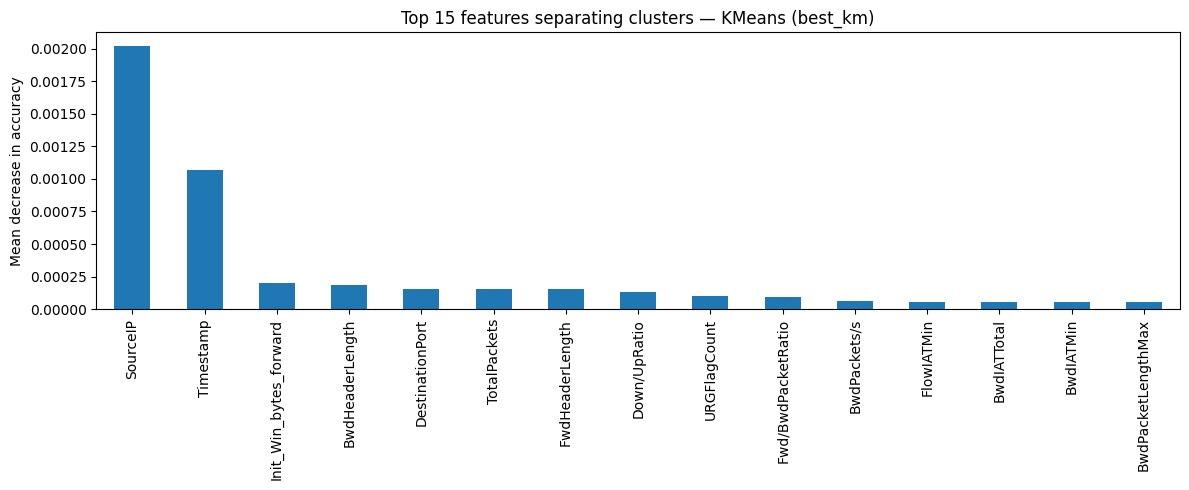

,perm_importance
SourceIP,0.002024
Timestamp,0.001069
Init_Win_bytes_forward,0.000197
BwdHeaderLength,0.000187
DestinationPort,0.000156
TotalPackets,0.000156
FwdHeaderLength,0.000156
Down/UpRatio,0.000135
URGFlagCount,0.000104
Fwd/BwdPacketRatio,0.000093


/tmp/ipykernel_5757/2087823681.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(top_importances.T, vert=False, labels=top_names)


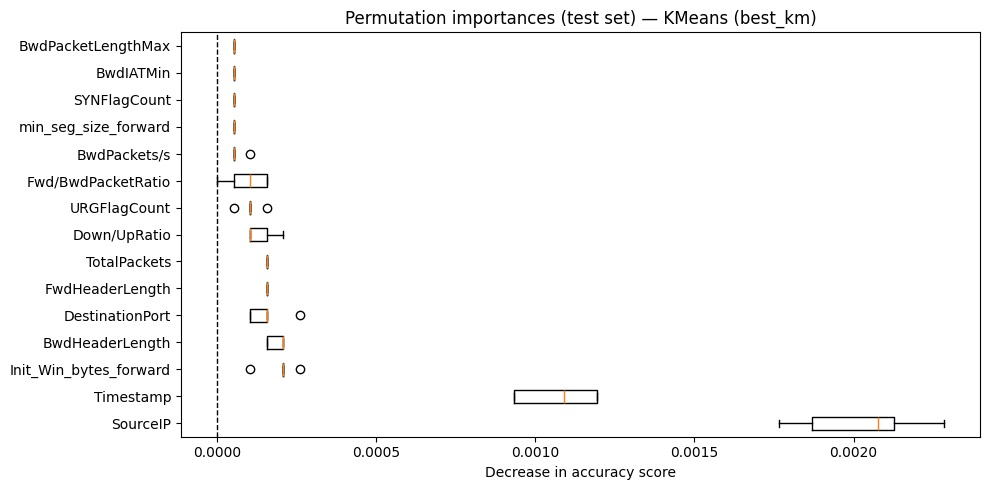

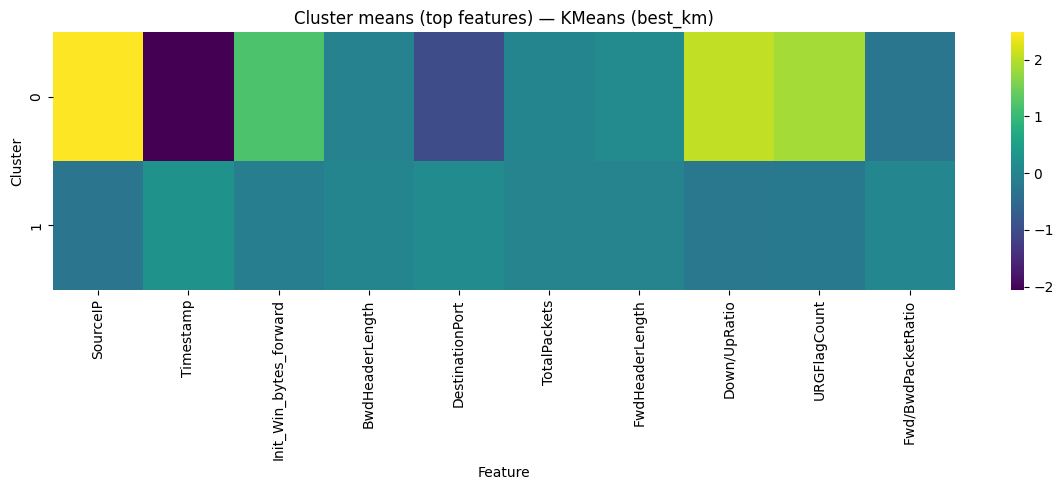


--- GMM (best_gmm) ---
Surrogate RF accuracy (predict cluster id): 0.9998


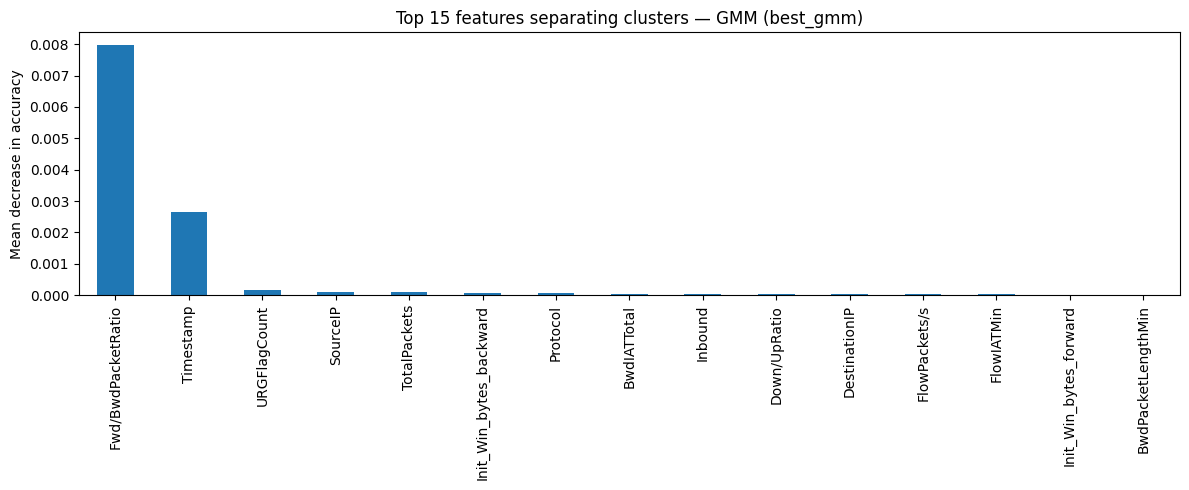

,perm_importance
Fwd/BwdPacketRatio,0.007980
Timestamp,0.002636
URGFlagCount,0.000166
SourceIP,0.000114
TotalPackets,0.000114
Init_Win_bytes_backward,0.000062
Protocol,0.000062
BwdIATTotal,0.000052
Inbound,0.000052
Down/UpRatio,0.000052


/tmp/ipykernel_5757/2087823681.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(top_importances.T, vert=False, labels=top_names)


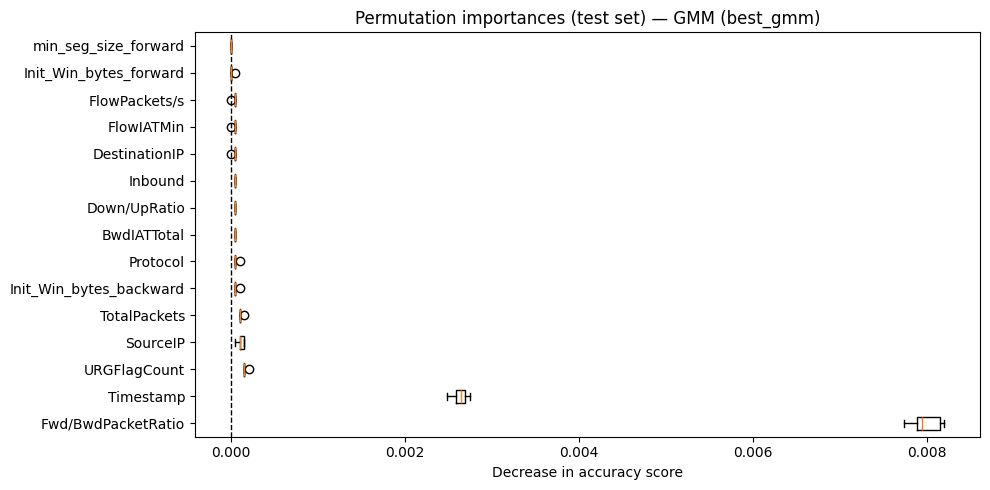

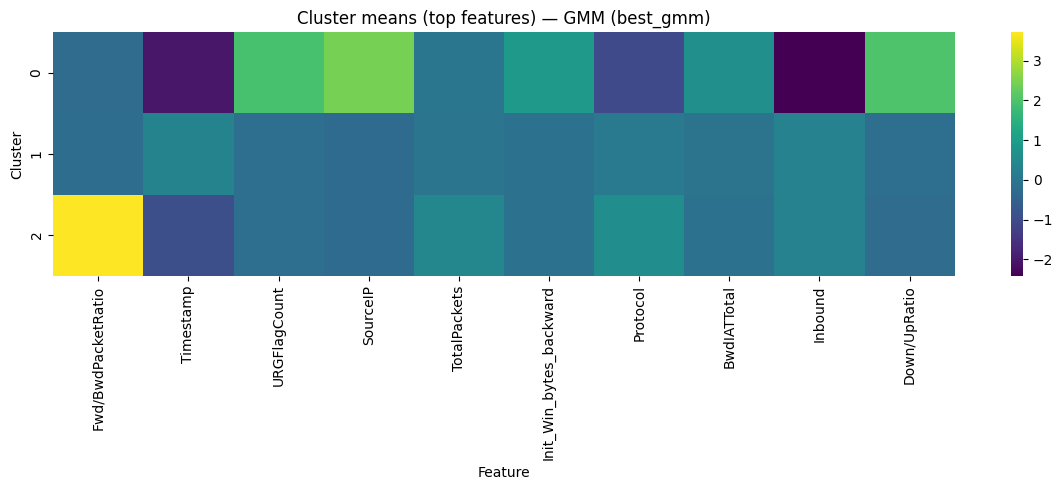

In [314]:
perm_km = explain_clusters_with_permutation(
    new_df, labels_km_full,
    title="KMeans (best_km)",
    top_n=15
)
perm_gmm = explain_clusters_with_permutation(
    new_df, labels_gmm_full,
    title="GMM (best_gmm)",
    top_n=15
)


--- KMeans (no IP/Timestamp) ---
Surrogate RF accuracy (predict cluster id): 0.9995


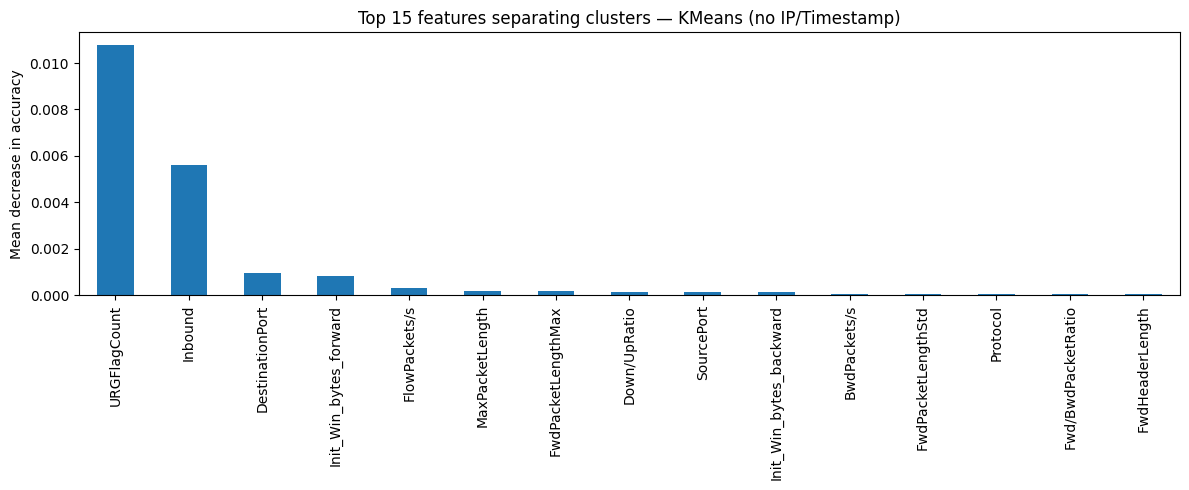

,perm_importance
URGFlagCount,0.010782
Inbound,0.005594
DestinationPort,0.000955
Init_Win_bytes_forward,0.000820
FlowPackets/s,0.000301
MaxPacketLength,0.000197
FwdPacketLengthMax,0.000187
Down/UpRatio,0.000156
SourcePort,0.000145
Init_Win_bytes_backward,0.000125


/tmp/ipykernel_5757/2087823681.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(top_importances.T, vert=False, labels=top_names)


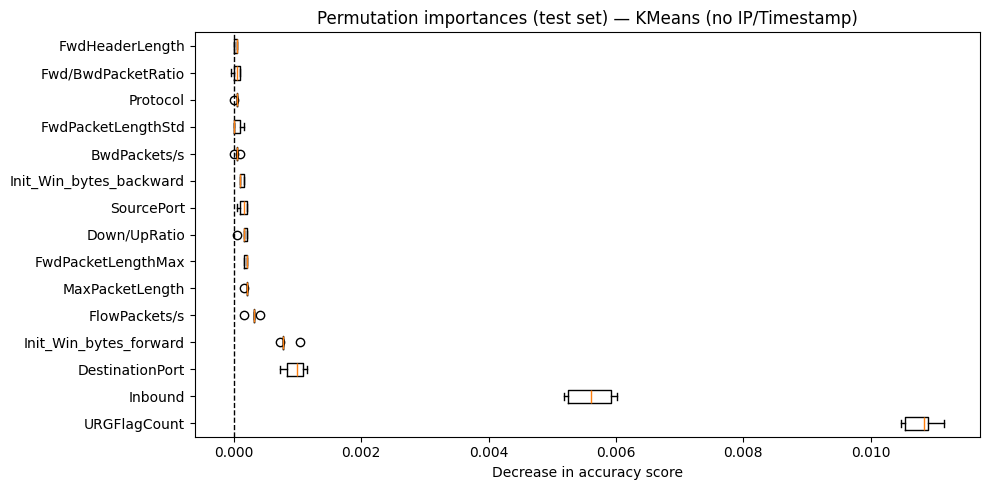

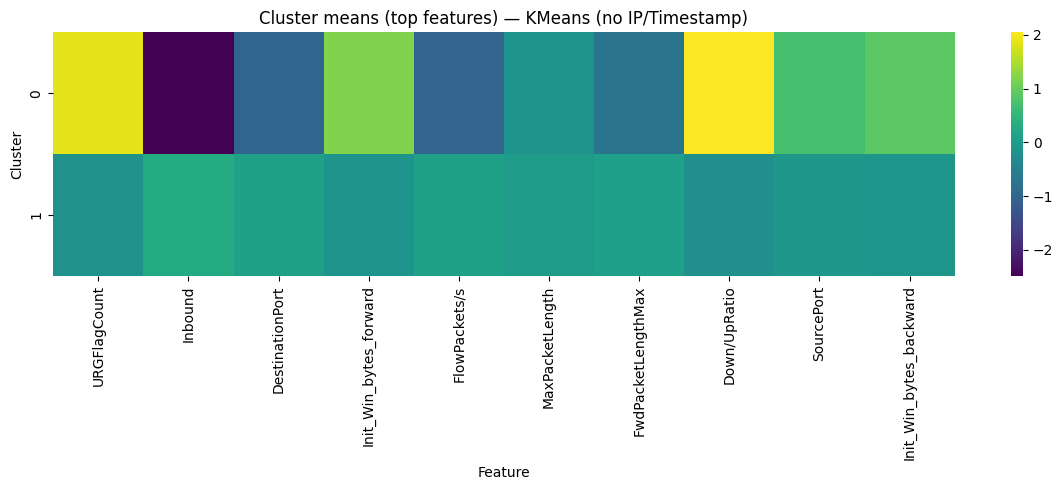


--- GMM (no IP/Timestamp) ---
Surrogate RF accuracy (predict cluster id): 0.9994


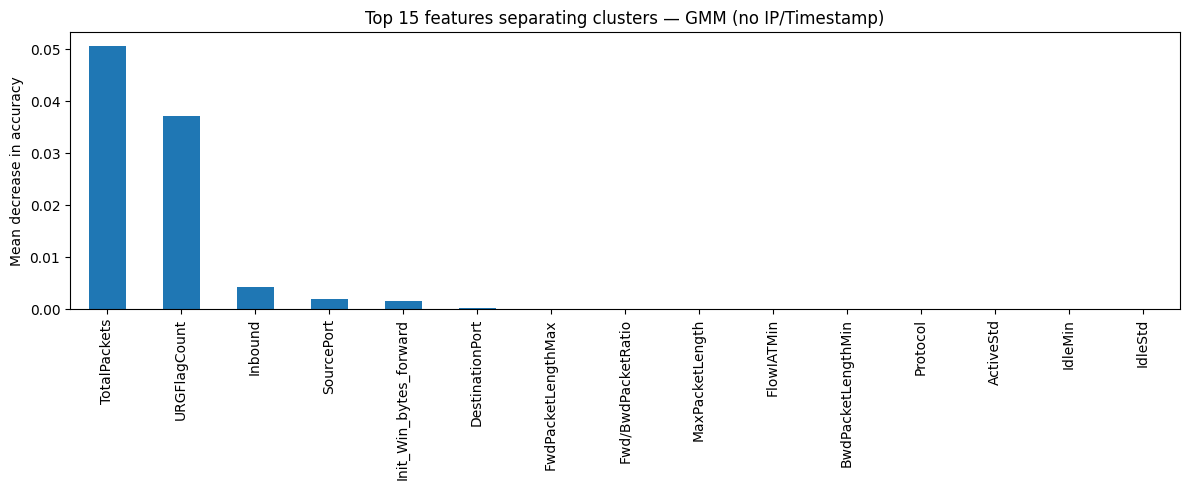

,perm_importance
TotalPackets,0.050706
URGFlagCount,0.037225
Inbound,0.004286
SourcePort,0.001982
Init_Win_bytes_forward,0.001557
DestinationPort,0.000228
FwdPacketLengthMax,0.000073
Fwd/BwdPacketRatio,0.000073
MaxPacketLength,0.000042
FlowIATMin,0.000000


/tmp/ipykernel_5757/2087823681.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(top_importances.T, vert=False, labels=top_names)


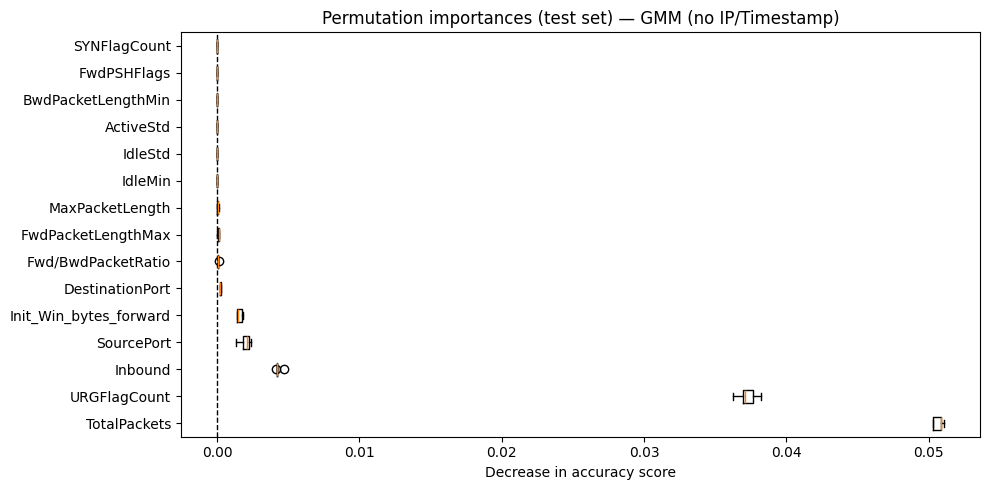

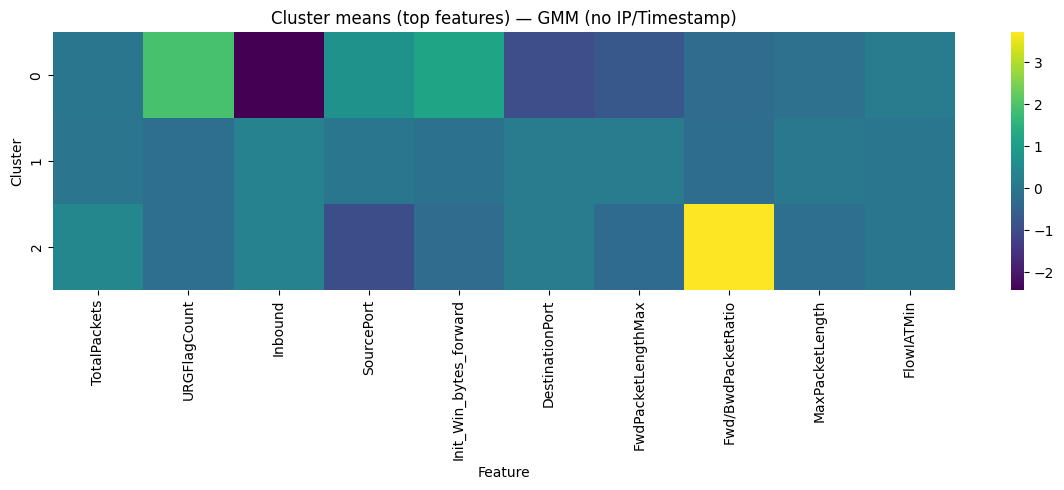

In [315]:
drop_cols = [c for c in ["SourceIP", "DestinationIP", "Timestamp"] if c in new_df.columns]
X_beh = new_df.drop(columns=drop_cols)

perm_imp_beh, acc_beh = explain_clusters_with_permutation(
    X_beh, labels_km_full, title="KMeans (no IP/Timestamp)", top_n=15
)

perm_imp_beh, acc_beh = explain_clusters_with_permutation(
    X_beh, labels_gmm_full, title="GMM (no IP/Timestamp)", top_n=15
)

## 4.3 - Identification sub-attack


### 4.a N subcluster

In [316]:
def subAttacc_clustering(X,y,label=""):
    print(f"For label = {label}")

    sub_df = X[y == label].copy()

    inertia = []
    sil = []

    # loop k
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels_k = km.fit_predict(sub_df.values)

        inertia.append(km.inertia_)
        sil.append(silhouette_score(sub_df.values, labels_k, metric="euclidean"))

    # best k
    best_idx = int(np.argmax(sil))
    best_k = list(k_range)[best_idx]
    best_sil = sil[best_idx]
    print(f"Best k (silhouette): {best_k} | silhouette={best_sil:.4f}")

    # fit finale su best_k
    best_km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
    best_labels = best_km.fit_predict(sub_df.values)

    # PCA 2D
    pca = PCA(n_components=2, random_state=42)
    proj = pca.fit_transform(sub_df.values)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # 1) elbow
    axs[0].plot(list(k_range), inertia, marker="o")
    axs[0].set_title("Elbow (Inertia)")
    axs[0].set_xlabel("k")
    axs[0].grid(True, linestyle="--", alpha=0.5)

    # 2) silhouette
    axs[1].plot(list(k_range), sil, marker="o", label="Silhouette")
    axs[1].axvline(best_k, color="red", linestyle="--", linewidth=1, label=f"best k={best_k}")
    axs[1].set_title("Silhouette (Euclidean)")
    axs[1].set_xlabel("k")
    axs[1].grid(True, linestyle="--", alpha=0.5)
    axs[1].legend()

    # 3) PCA scatter dei subcluster
    sc = axs[2].scatter(proj[:, 0], proj[:, 1], c=best_labels, s=6, cmap="viridis", alpha=0.7)
    axs[2].set_title(f"Sub-clusters (PCA2D) | k={best_k}")
    axs[2].set_xlabel("PC1")
    axs[2].set_ylabel("PC2")
    axs[2].grid(True, linestyle="--", alpha=0.5)

    plt.suptitle(f"Sub-attack clustering within class: {label}", y=1.02)
    plt.tight_layout()
    plt.show()

    return best_k

For label = ddos_dns
Best k (silhouette): 2 | silhouette=0.6955


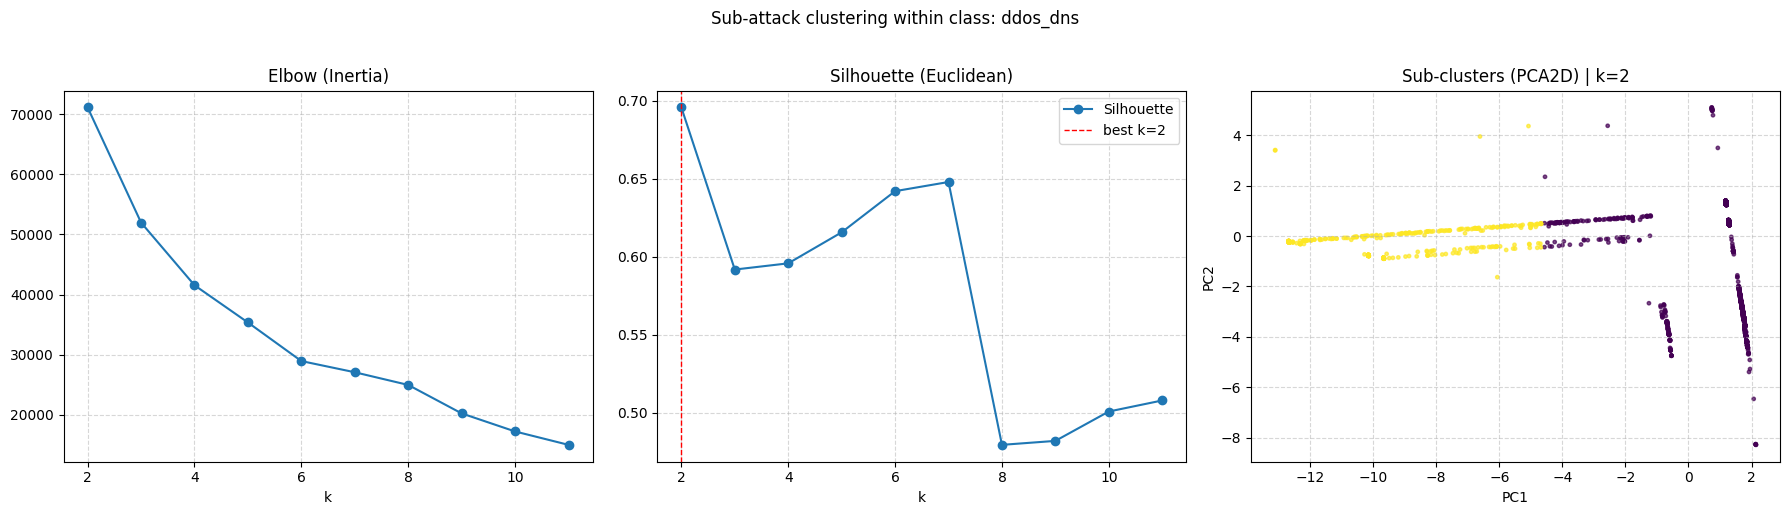

For label = benign
Best k (silhouette): 2 | silhouette=0.4601


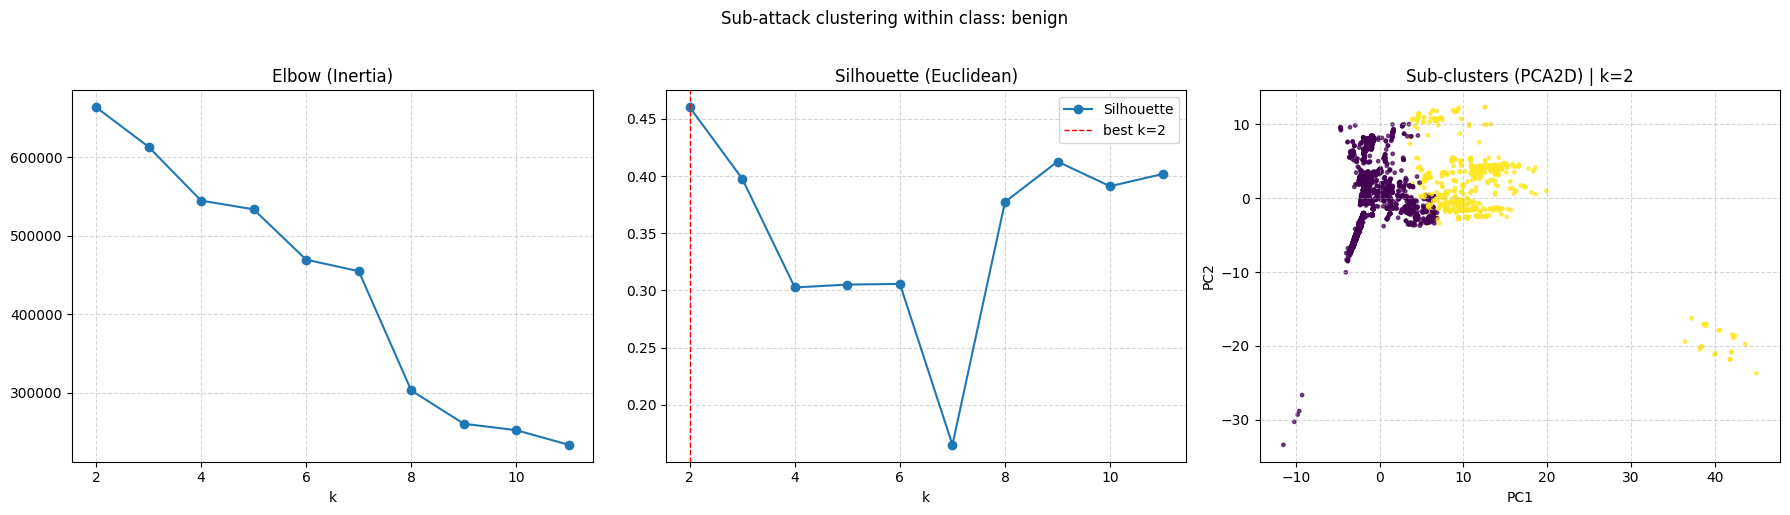

For label = ddos_ldap
Best k (silhouette): 3 | silhouette=0.7336


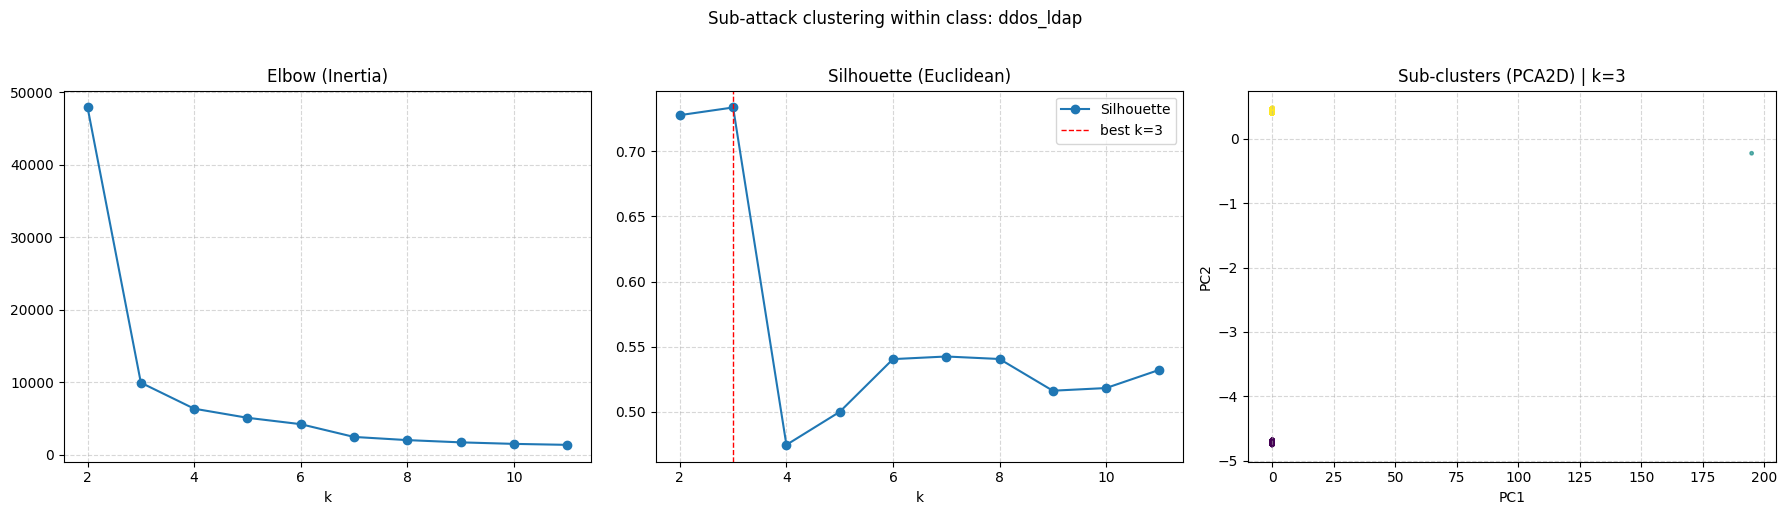

For label = ddos_mssql
Best k (silhouette): 11 | silhouette=0.5328


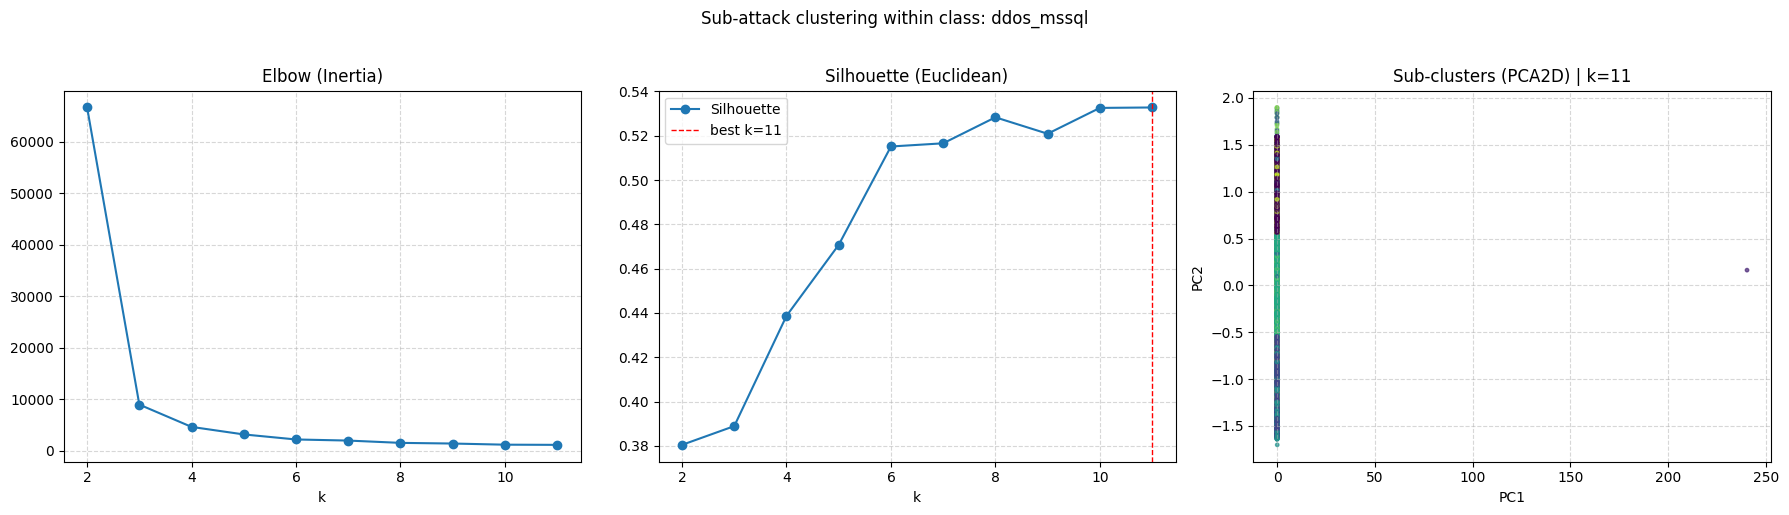

For label = ddos_netbios
Best k (silhouette): 2 | silhouette=0.7064


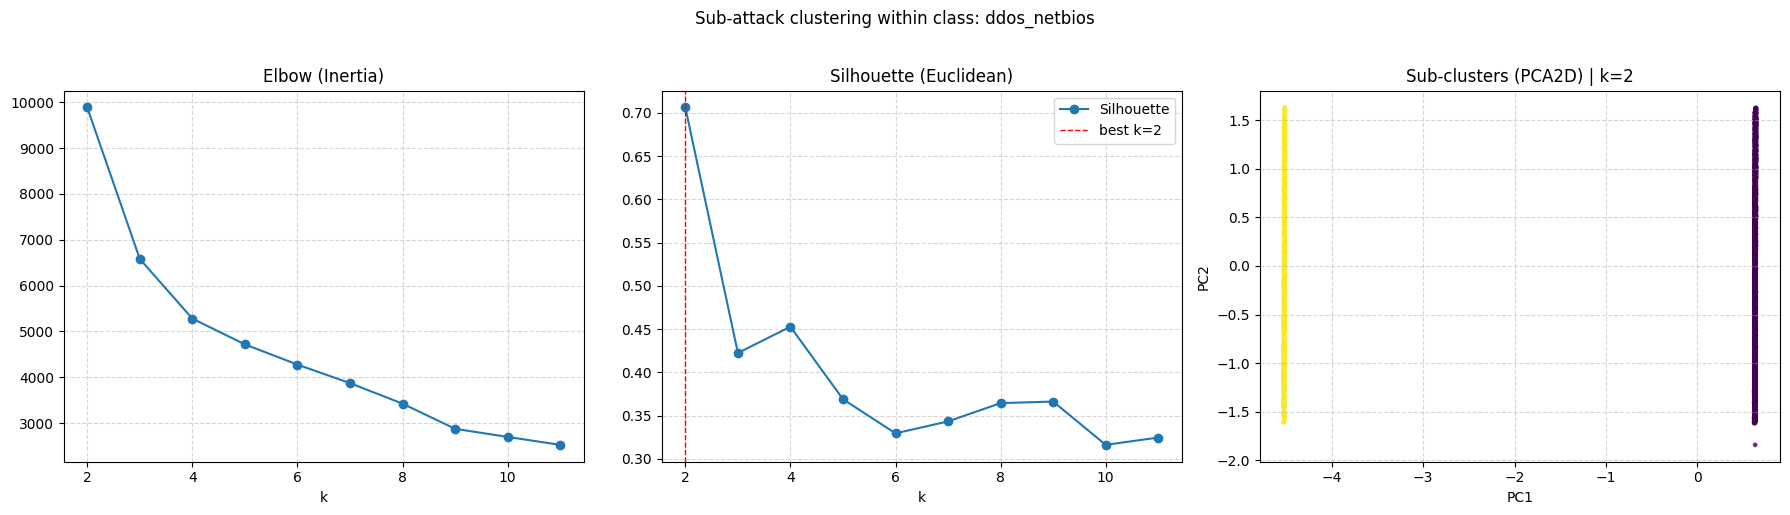

For label = ddos_ntp
Best k (silhouette): 2 | silhouette=0.9165


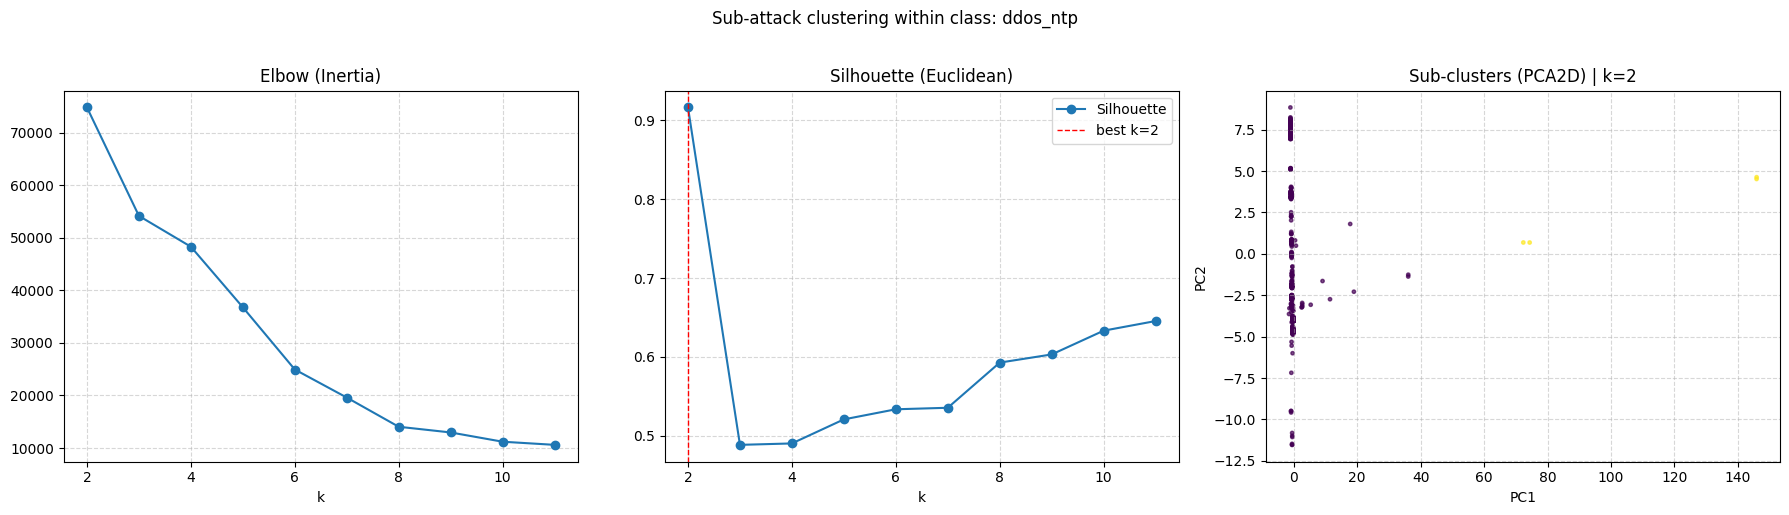

For label = ddos_snmp
Best k (silhouette): 8 | silhouette=0.5755


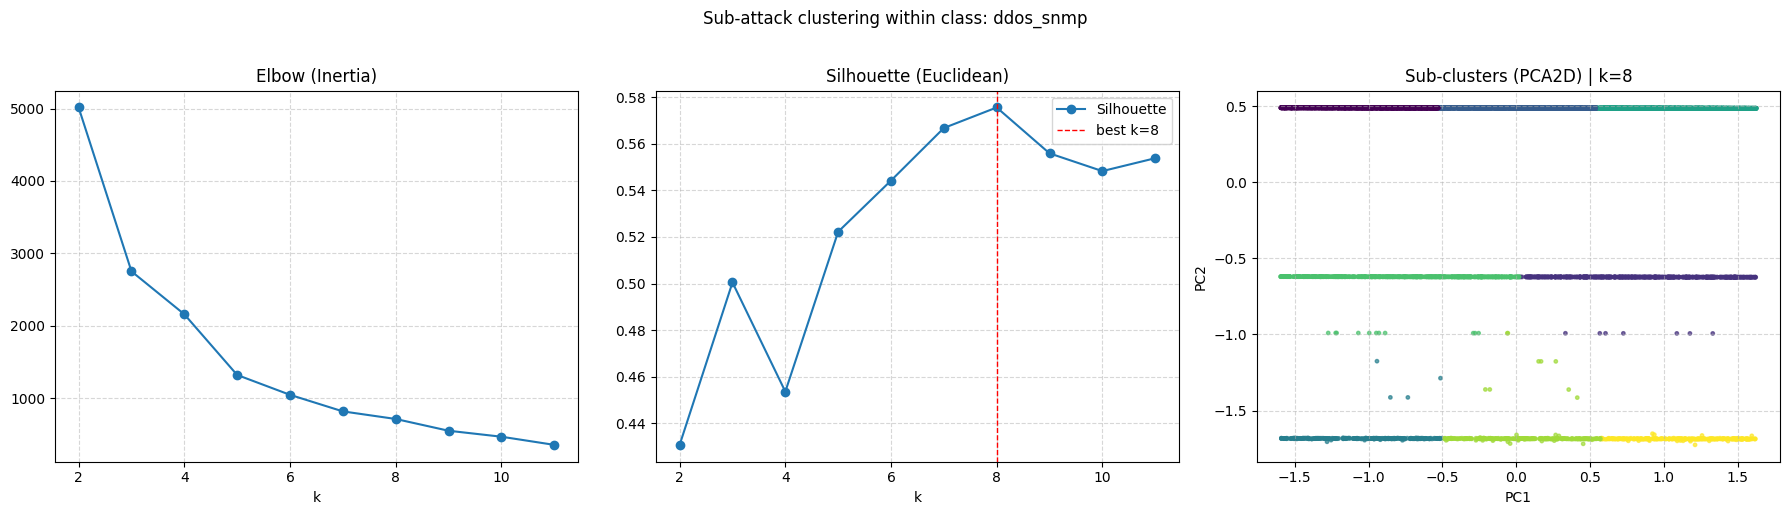

For label = ddos_ssdp
Best k (silhouette): 3 | silhouette=0.7552


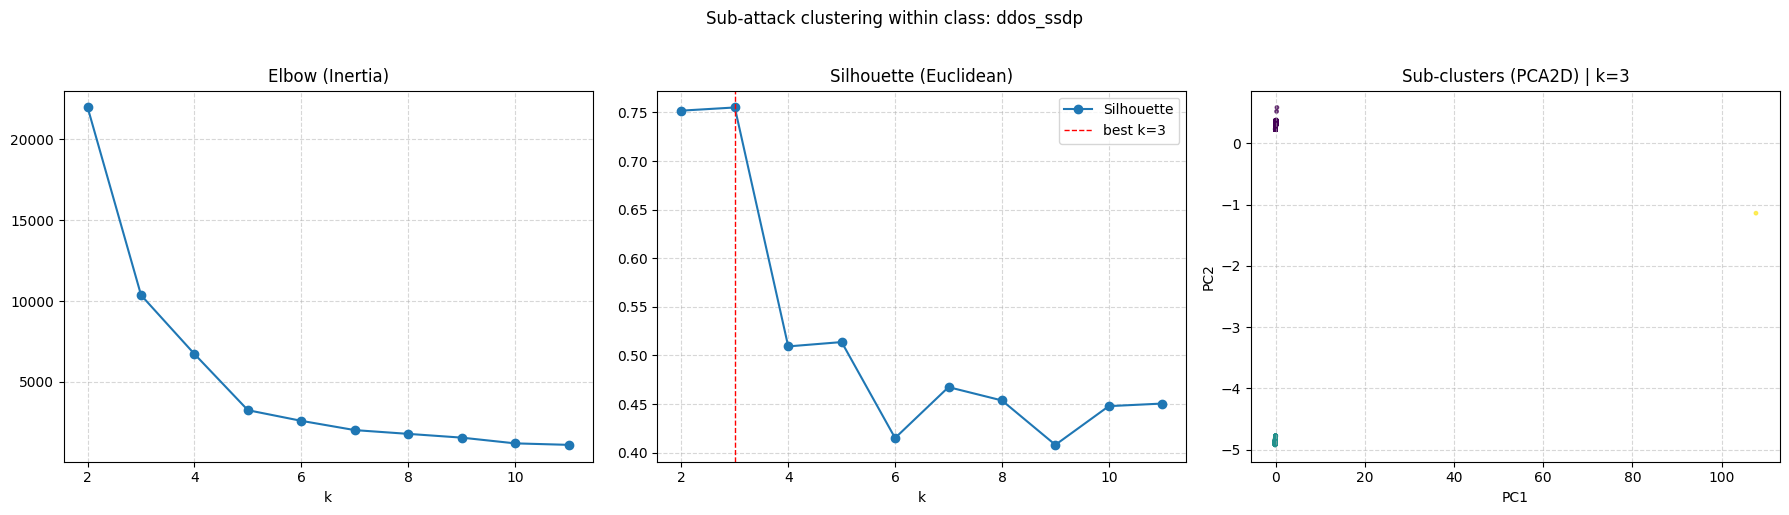

For label = ddos_udp
Best k (silhouette): 3 | silhouette=0.5163


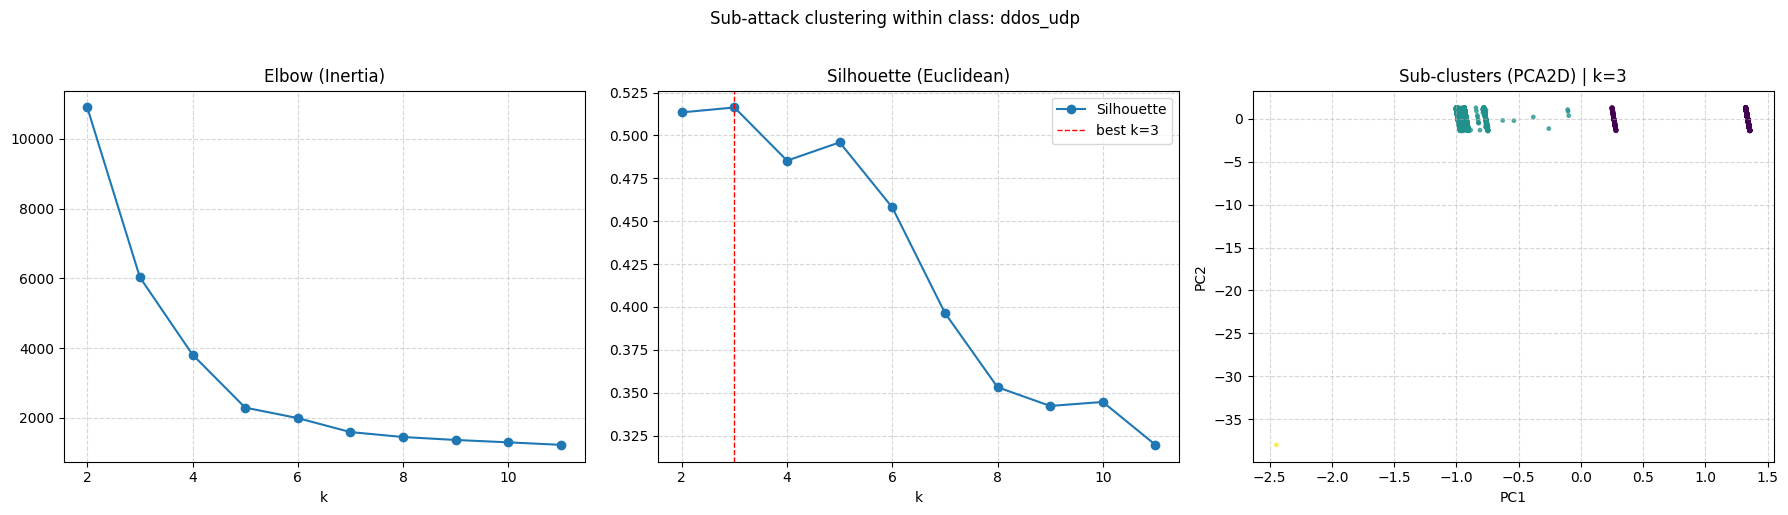

For label = ddos_syn
Best k (silhouette): 2 | silhouette=0.7276


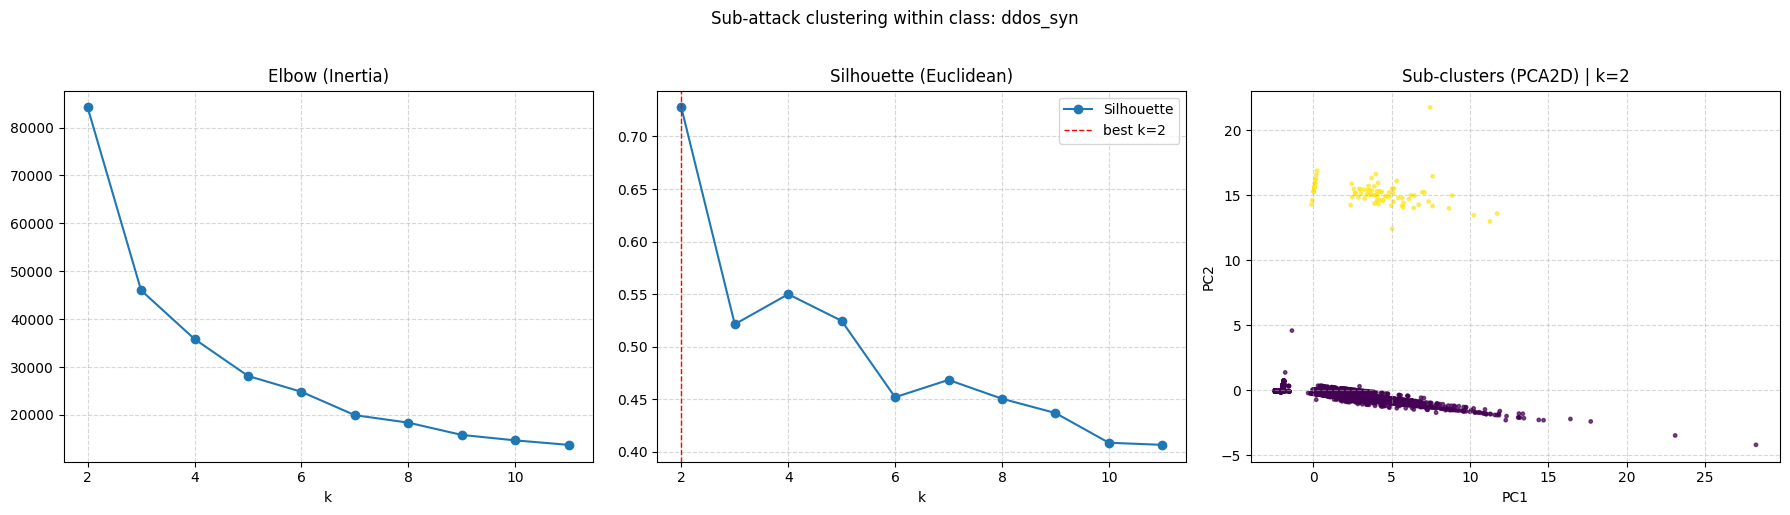

For label = ddos_tftp
Best k (silhouette): 2 | silhouette=0.8448


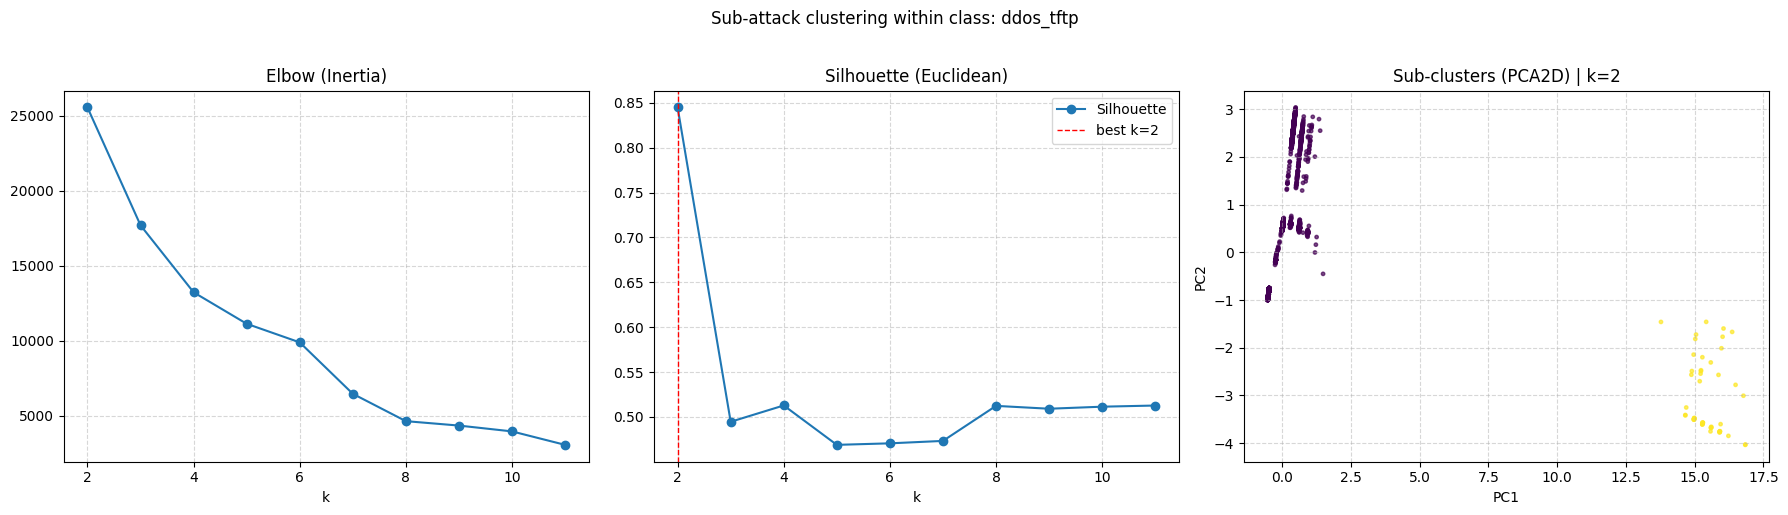

For label = ddos_udp_lag
Best k (silhouette): 4 | silhouette=0.4744


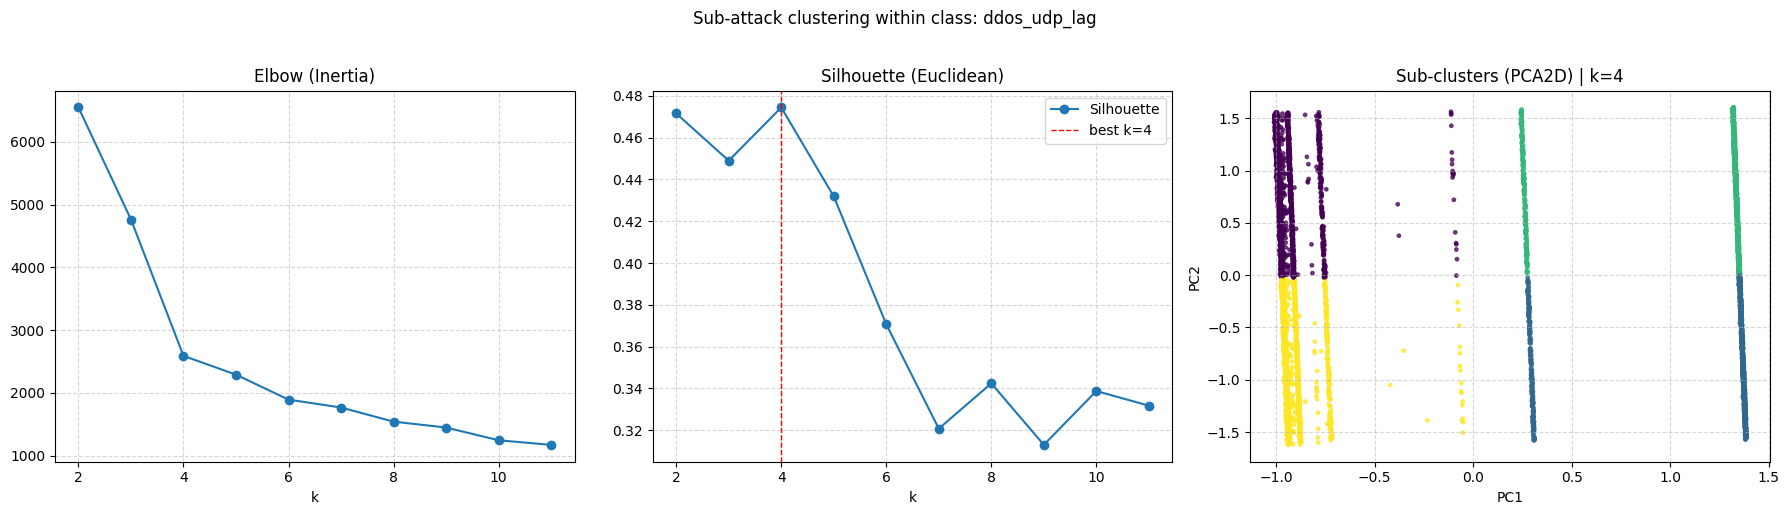

[{'label': 'ddos_dns', 'best_k': 2}, {'label': 'benign', 'best_k': 2}, {'label': 'ddos_ldap', 'best_k': 3}, {'label': 'ddos_mssql', 'best_k': 11}, {'label': 'ddos_netbios', 'best_k': 2}, {'label': 'ddos_ntp', 'best_k': 2}, {'label': 'ddos_snmp', 'best_k': 8}, {'label': 'ddos_ssdp', 'best_k': 3}, {'label': 'ddos_udp', 'best_k': 3}, {'label': 'ddos_syn', 'best_k': 2}, {'label': 'ddos_tftp', 'best_k': 2}, {'label': 'ddos_udp_lag', 'best_k': 4}]


In [317]:


subAttack_list_inf = []
for l in label_df['label'].unique():
    b_k = subAttacc_clustering(new_df, label_df['label'], label=l)
    subAttack_list_inf.append(
        {
            "label": l,
            "best_k": b_k,
        }
    )
print (subAttack_list_inf)

### 3.b
#### Similar attack

In [318]:
prof = new_df.copy()
prof["GT"] = label_df["label"].values

#display(prof.head())

prog = prof.groupby("GT").median()

pairs = []
classes = prog.index.tolist()

for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        a, b = classes[i], classes[j]
        d = np.linalg.norm(prog.loc[a].values - prog.loc[b].values)  # euclidean
        pairs.append((a, b, d))

pairs_df = pd.DataFrame(pairs, columns=["class_A", "class_B", "euclid_dist"]).sort_values("euclid_dist").reset_index(drop=True)
display(pairs_df.head(10)) #top 10 similar classes
display(pairs_df.tail(10)) #top 10 dissimilar classes

,class_A,class_B,euclid_dist
0,ddos_ldap,ddos_mssql,0.143339
1,ddos_udp,ddos_udp_lag,0.604244
2,ddos_mssql,ddos_ssdp,1.329445
3,ddos_ldap,ddos_ssdp,1.413015
4,ddos_netbios,ddos_snmp,1.567163
5,ddos_syn,ddos_tftp,2.273253
6,ddos_netbios,ddos_udp,2.425762
7,ddos_netbios,ddos_udp_lag,2.487940
8,ddos_mssql,ddos_netbios,2.490366
9,ddos_ldap,ddos_netbios,2.504687


,class_A,class_B,euclid_dist
56,ddos_ldap,ddos_ntp,7.263590
57,ddos_ntp,ddos_ssdp,7.265300
58,ddos_mssql,ddos_ntp,7.300994
59,benign,ddos_tftp,7.335376
60,benign,ddos_snmp,7.429156
61,ddos_dns,ddos_ntp,7.482808
62,benign,ddos_ldap,7.836103
63,benign,ddos_ssdp,7.836978
64,benign,ddos_mssql,7.871118
65,benign,ddos_dns,8.057409


In [319]:
def plot_feature_differences(profiles, class_A, class_B, top_n=15):
    feat_diffs = (profiles.loc[class_A] - profiles.loc[class_B]).abs().sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(12, 4))
    plt.bar(feat_diffs.index, feat_diffs.values)
    plt.xticks(rotation=90, ha="right")
    plt.title(f"Top {top_n} feature differences: {class_A} vs {class_B}")
    plt.ylabel("Absolute difference (median)")
    plt.tight_layout()
    plt.show()

    return feat_diffs



Most similar pair: ddos_ldap vs ddos_mssql | dist = 0.1433


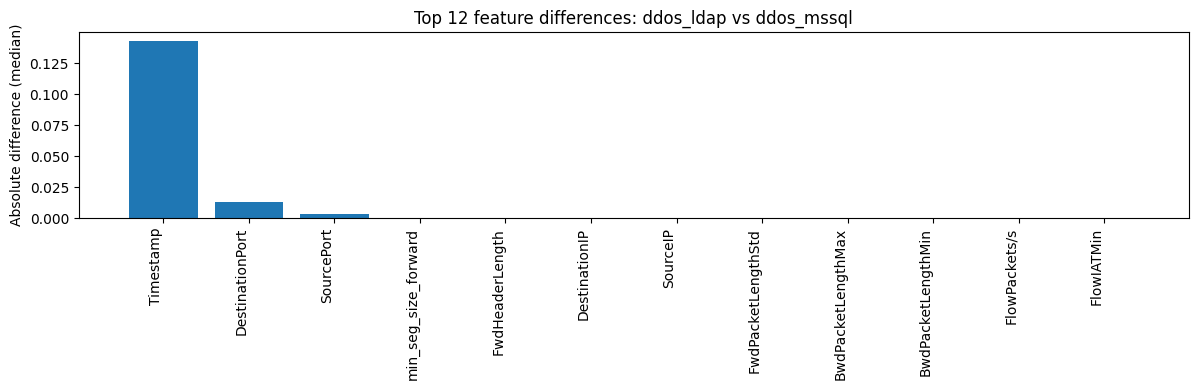

Most similar pair: ddos_udp vs ddos_udp_lag | dist = 0.6042


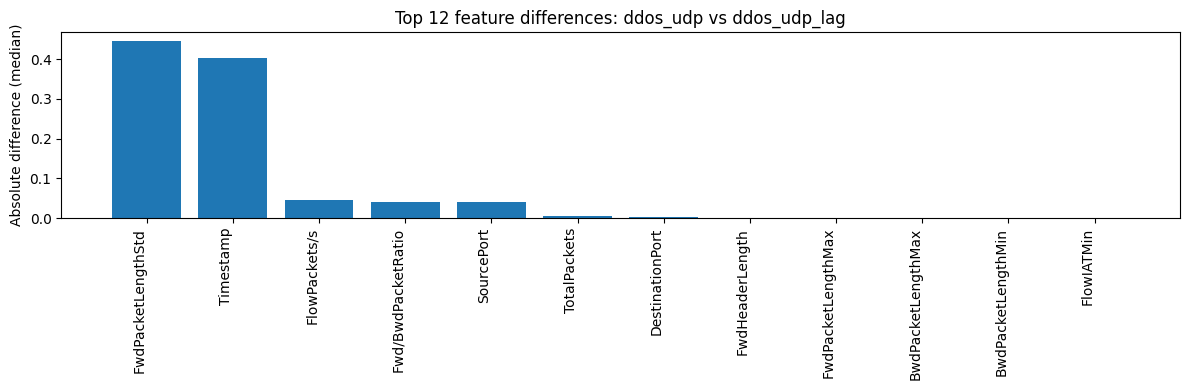

Most similar pair: ddos_mssql vs ddos_ssdp | dist = 1.3294


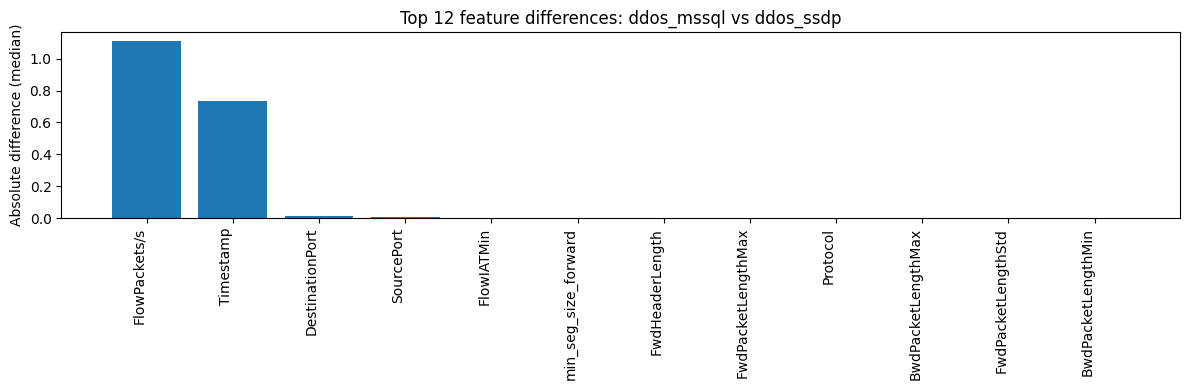

Most dissimilar pair: benign vs ddos_dns | dist = 8.0574


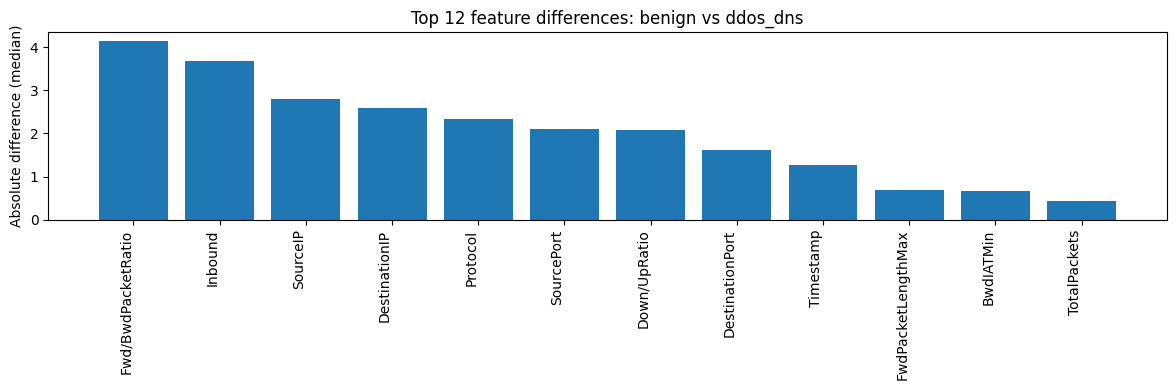

Most dissimilar pair: benign vs ddos_mssql | dist = 7.8711


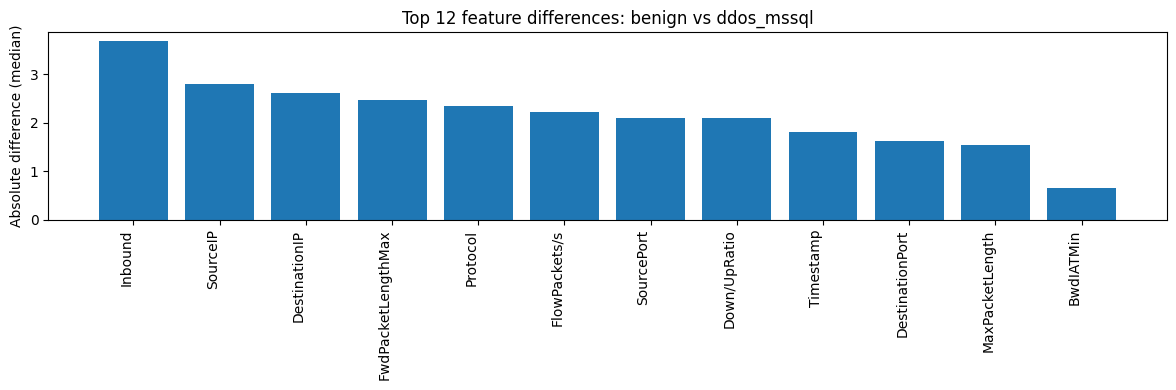

Most dissimilar pair: benign vs ddos_ssdp | dist = 7.837


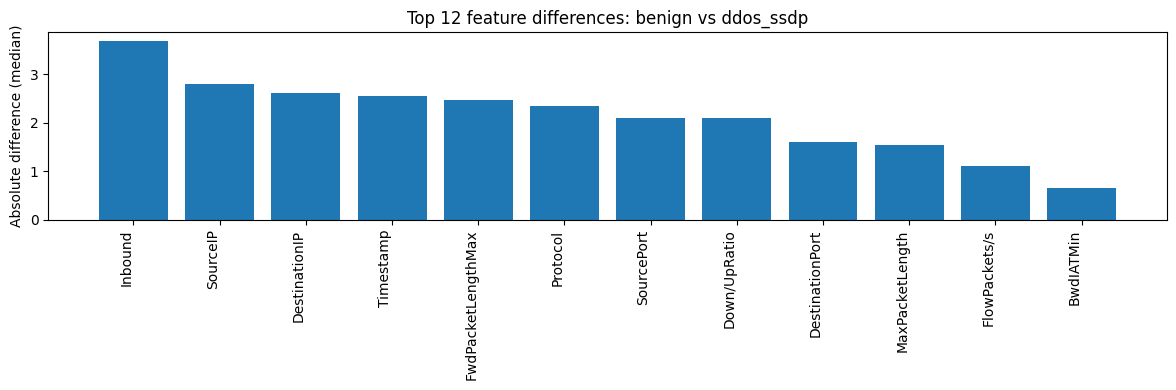

In [320]:
# top 3 più simili
for i in range(3):
    a = pairs_df.loc[i, "class_A"]
    b = pairs_df.loc[i, "class_B"]
    print("Most similar pair:", a, "vs", b, "| dist =", round(pairs_df.loc[i, "euclid_dist"], 4))
    plot_feature_differences(prog, a, b, top_n=12)

# top 3 più diverse
for i in range(1, 4):
    a = pairs_df.iloc[-i]["class_A"]
    b = pairs_df.iloc[-i]["class_B"]
    print("Most dissimilar pair:", a, "vs", b, "| dist =", round(pairs_df.iloc[-i]["euclid_dist"], 4))
    plot_feature_differences(prog, a, b, top_n=12)